# PrizePicks Machine Learning Prediction

## Probabilities of Each Parlay

We will begin by creating functions to calculate the ROI's of each parlay type

In [3]:
import numpy as np
import pandas as pd
from scipy.stats import binom

# set probability of hitting
p = 0.5

C:\Users\Zachary Chan\New folder\Lib\site-packages\pandas\core\arrays\masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [4]:
# 2 man power

def power_2_return(p):
    probability = p**2
    payout = 3

    power_2_return = probability * payout
    power_2_roi = power_2_return - 1
    return power_2_roi

In [5]:
# 3 man power

def power_3_return(p):
    probability = p**3
    payout = 6

    power_3_return = probability * payout
    power_3_roi = power_3_return - 1
    return power_3_roi

In [6]:
# 4 man power

def power_4_return(p):
    probability = p**4
    payout = 10

    power_4_return = probability * payout
    power_4_roi = power_4_return - 1
    return power_4_roi

In [7]:
# 5 man power

def power_5_return(p):
    probability = p**5
    payout = 20

    power_5_return = probability * payout
    power_5_roi = power_5_return - 1
    return power_5_roi

In [8]:
# 6 man power

def power_6_return(p):
    probability = p**6
    payout = 37.5

    power_6_return = probability * payout
    power_6_roi = power_6_return - 1
    return power_6_roi

In [9]:
# 3 pick flex

def flex_3_return(p):
    prob_hit_3 = p**3
    payout_3 = 3

    prob_hit_2 = binom.pmf(2, 3, p)
    payout_2 = 1

    flex_3_return = prob_hit_3*payout_3 + prob_hit_2*payout_2
    flex_3_roi = flex_3_return - 1
    return flex_3_roi

In [10]:
# 3 pick flex

def flex_3_return(p):
    prob_hit_3 = p**3
    payout_3 = 3

    prob_hit_2 = binom.pmf(2, 3, p)
    payout_2 = 1

    flex_3_return = prob_hit_3*payout_3 + prob_hit_2*payout_2
    flex_3_roi = flex_3_return - 1
    return flex_3_roi

In [11]:
# 4 pick flex

def flex_4_return(p):
    prob_hit_4 = p**4
    payout_4 = 6
    
    prob_hit_3 = binom.pmf(3, 4, p)
    payout_3 = 1.5

    flex_4_return = prob_hit_4*payout_4 + prob_hit_3*payout_3
    flex_4_roi = flex_4_return - 1
    return flex_4_roi

In [12]:
# 5 pick flex

def flex_5_return(p):
    prob_hit_5 = p**5
    payout_5 = 10
    
    prob_hit_4 = binom.pmf(4, 5, p)
    payout_4 = 2

    
    prob_hit_3 = binom.pmf(3, 5, p)
    payout_3 = 0.4

    flex_5_return = prob_hit_5*payout_5 + prob_hit_4*payout_4 + prob_hit_3*payout_3
    flex_5_roi = flex_5_return - 1
    return flex_5_roi

In [13]:
# 6 pick flex

def flex_6_return(p):
    prob_hit_6 = p**6
    payout_6 = 25

    prob_hit_5 = binom.pmf(5, 6, p)
    payout_5 = 2

    prob_hit_4 = binom.pmf(4, 6, p)
    payout_4 = 0.4
    flex_6_return = prob_hit_6*payout_6 + prob_hit_5*payout_5 + prob_hit_4*payout_4
    flex_6_roi = flex_6_return - 1
    return flex_6_roi

Here is a table of the estimated return for each parlay

In [14]:
# create dictionary to organize data
parlay_info_dict = {
    "Parlay": ["2 Power", "3 Power", "4 Power", "5 Power", "6 Power", "3 Flex", "4 Flex", "5 Flex", "6 Flex", ],
    "Return": [power_2_return(p), power_3_return(p), power_4_return(p), power_5_return(p), power_6_return(p), flex_3_return(p), flex_4_return(p), flex_5_return(p), flex_6_return(p)]
}

# create DataFrame to display
parlay_info_df = pd.DataFrame(parlay_info_dict)
parlay_info_df

,Parlay,Return
0,2 Power,-0.250000
1,3 Power,-0.250000
2,4 Power,-0.375000
3,5 Power,-0.375000
4,6 Power,-0.414062
5,3 Flex,-0.250000
6,4 Flex,-0.250000
7,5 Flex,-0.250000
8,6 Flex,-0.328125


The results show that all parlays have a negative return. In other words, when the probibility of each leg is 0.5, we are always predicted to lose money, no matter which parlay we choose.

Below is a table of the estimated return of each parlay when the probability of winning each leg is 55%. Now, we can see that some parlays are estimated to make money. The 6 pick flex appears to be the best perfermer here with a ROI of 7.5%. Therefore, if we can build a model that correctly predicts with probability of 0.55, we can make money, theoretically.

In [15]:
# set probability of success to 0.55
p = 0.55

# create dictionary to organize data
parlay_info_dict = {
    "Parlay": ["2 Power", "3 Power", "4 Power", "5 Power", "6 Power", "3 Flex", "4 Flex", "5 Flex", "6 Flex", ],
    "Return": [power_2_return(p), power_3_return(p), power_4_return(p), power_5_return(p), power_6_return(p), flex_3_return(p), flex_4_return(p), flex_5_return(p), flex_6_return(p)]
}

# create DataFrame to display
parlay_info_df = pd.DataFrame(parlay_info_dict)
parlay_info_df

,Parlay,Return
0,2 Power,-0.092500
1,3 Power,-0.001750
2,4 Power,-0.084937
3,5 Power,0.006569
4,6 Power,0.038024
5,3 Flex,-0.092500
6,4 Flex,-0.001750
7,5 Flex,0.049826
8,6 Flex,0.074970


Lastly, we will look at the ROI's when the probabability of winning is 0.6. Although achieving this accuracy would be very difficult, we can see that 6 man power and 6 pick flex are the best options for this case.

In [ ]:
# set probability of success to 0.6
p = 0.53

# create dictionary to organize data
parlay_info_dict = {
    "Parlay": ["2 Power", "3 Power", "4 Power", "5 Power", "6 Power", "3 Flex", "4 Flex", "5 Flex", "6 Flex", ],
    "Return": [power_2_return(p), power_3_return(p), power_4_return(p), power_5_return(p), power_6_return(p), flex_3_return(p), flex_4_return(p), flex_5_return(p), flex_6_return(p)]
}

# create DataFrame to display
parlay_info_df = pd.DataFrame(parlay_info_dict)
parlay_info_df

## Scraping Data

Using xPath, we will scrape data from Basketball Reference.

In [17]:
import requests
import lxml.html as lx

The first type of data we will look at is individual player data. After inspecting the player data, I decided that features that could be useful for predicting points are date, opponent, and home/away.

In [187]:
# create function get player data for desired player and year

dates_list = []
opp_list = []
location_list = []
point_list = []
assist_list = []
rebound_list = []
minutes_list = []
fga_list = []
fg_pct_list = []

def get_player_data(url, year):
    
    endpoint = url + year
    result = requests.get(endpoint)
    html = lx.fromstring(result.text)

    # scrape dates of games from 2025
    date_data = html.xpath('//td[@data-stat="date_game"]/a')
    for i in date_data:
        dates_list.append(i.text)

    # scrape opponents of games from 2025
    opp_data = html.xpath('//td[@data-stat="opp_id"]/a')
    for i in opp_data:
        opp_list.append(i.text)

    # scrape home or away data from 2025
    location_data = html.xpath('//td[@data-stat="game_location"]')
    for i in location_data:
        if i.text == '@':
            location_list.append('Away')
        if i.text == None:
            location_list.append('Home')

    # scrape points of games from 2025
    point_data = html.xpath('//td[@data-stat="pts"]')
    for i in point_data:
        point_list.append(i.text)
        
    # scrape assists of games from 2025
    assist_data = html.xpath('//td[@data-stat="ast"]')
    for i in assist_data:
        assist_list.append(i.text)
        
    # scrape rebounds of games from 2025
    rebound_data = html.xpath('//td[@data-stat="trb"]')
    for i in rebound_data:
        rebound_list.append(i.text)
        
    # scrape minutes played of games from 2025
    minutes_data = html.xpath('//td[@data-stat="mp"]')
    for i in minutes_data:
        minutes_list.append(i.text)
        
    # scrape fga of games from 2025
    fga_data = html.xpath('//td[@data-stat="fga"]')
    for i in fga_data:
        fga_list.append(i.text)
        
    # scrape fg_pct of games from 2025
    fg_pct_data = html.xpath('//td[@data-stat="fg_pct"]')
    for i in fg_pct_data:
        fg_pct_list.append(i.text)

In [188]:
# run function for 2025

url = 'https://www.basketball-reference.com/wnba/players/r/reesean01w/gamelog/'
year = '2025'
get_player_data(url, year)

In [189]:
# run function for 2024

url = 'https://www.basketball-reference.com/wnba/players/r/reesean01w/gamelog/'
year = '2024'
get_player_data(url, year)

In [190]:
# create dataframe
data_dict = {
    'Date': dates_list,
    'Opp': opp_list,
    'Location': location_list,
    'PTS': point_list,
    'AST': assist_list,
    'REB': rebound_list,
    'Min': minutes_list,
    'FGA': fga_list,
    'FG_pct': fg_pct_list
}
df = pd.DataFrame(data_dict)
df.head()

,Date,Opp,Location,PTS,AST,REB,Min,FGA,FG_pct
0,2025-05-17,IND,Away,12,1,17,24:56,14,.357
1,2025-05-22,NYL,Home,2,1,12,26:56,8,.000
2,2025-05-25,LAS,Away,13,4,12,31:51,11,.455
3,2025-05-27,PHO,Away,13,3,15,33:39,9,.333
4,2025-05-29,DAL,Home,6,5,9,25:04,6,.333


This is what the first 5 lines of the dataframe looks like.

Next, we will look at data for the opponents. This data could be useful for predictions because each team plays at different paces and has unique defensive tendencies.

We will begin by creating a function to get per-game-stats.

In [22]:
def retrieve_rows_per_game(html): 
    per_game_table = html.xpath('//table[@id="per_game-team"]//tr')
    cells = []
    for row in per_game_table: 
        # ./td|th means we start at the node (not searching the whole doc again), and choose td OR th children
        cells.append([cell.text_content() for cell in row.xpath('./td|th')]) # no text, as some cells are in <b>
    return cells

Next, we will make a function to get advanced team stats

In [23]:
def retrieve_rows_advanced_team(html): 
    per_game_table = html.xpath('//table[@id="advanced-team"]//tr')
    cells = []
    for row in per_game_table: 
        # ./td|th means we start at the node (not searching the whole doc again), and choose td OR th children
        cells.append([cell.text_content() for cell in row.xpath('./td|th')]) # no text, as some cells are in <b>
    return cells

Lastly, we will get league standings

In [24]:
def retrieve_rows_standings(html): 
    per_game_table = html.xpath('//table[@id="wnba_standings"]//tr')
    cells = []
    for row in per_game_table: 
        # ./td|th means we start at the node (not searching the whole doc again), and choose td OR th children
        cells.append([cell.text_content() for cell in row.xpath('./td|th')]) # no text, as some cells are in <b>
    return cells

Now, we will create a function puts the data into dataframes

In [25]:
year = str(2025)

opp_team_data_list = []
def get_opp_team_data(year):
    endpoint = 'https://www.basketball-reference.com/wnba/years/' + year + '.html'
    result = requests.get(endpoint)
    html = lx.fromstring(result.text)
    
    per_game_df = pd.DataFrame(retrieve_rows_per_game(html))
    advanced_team_df = pd.DataFrame(retrieve_rows_advanced_team(html))
    advanced_team_df = advanced_team_df[1:]
    standings_df = pd.DataFrame(retrieve_rows_standings(html))
    
    opp_team_data_list.append(per_game_df)
    opp_team_data_list.append(advanced_team_df)
    opp_team_data_list.append(standings_df)

In [26]:
# run the function
get_opp_team_data(year)

Now we have a list of 3 dataframes about the oppenents. The 3 dataframes are shown below.

In [27]:
opp_team_data_list[0].head()

,0,1,2,3,4,5,6,7,8,9,...,15,16,17,18,19,20,21,22,23,24
0,Rk,Team,G,MP,FG,FGA,FG%,3P,3PA,3P%,...,FT%,ORB,DRB,TRB,AST,STL,BLK,TOV,PF,PTS
1,1,New York Liberty,21,200.0,30.1,66.8,.451,10.0,28.4,.353,...,.824,7.2,27.4,34.6,21.6,8.8,4.9,12.7,16.9,86.9
2,2,Minnesota Lynx,24,201.0,31.3,68.3,.458,9.3,26.6,.351,...,.804,8.3,25.8,34.1,23.6,8.3,5.2,12.4,16.8,84.7
3,3,Indiana Fever,23,200.0,30.9,67.7,.457,7.9,23.8,.330,...,.759,8.4,25.6,34.0,20.2,7.2,3.1,12.7,19.5,84.2
4,4,Atlanta Dream,22,201.1,29.2,68.0,.430,9.3,28.8,.323,...,.757,9.3,28.3,37.5,21.0,6.4,4.5,11.8,17.1,83.8


In [28]:
opp_team_data_list[1].head()

,0,1,2,3,4,5,6,7,8,9,...,19,20,21,22,23,24,25,26,27,28
1,Rk,Team,Age,W,L,PW,PL,MOV,SOS,SRS,...,TOV%,ORB%,FT/FGA,,eFG%,TOV%,DRB%,FT/FGA,,Arena
2,1,Minnesota Lynx,28.8,20,4,20,4,9.71,-2.03,7.68,...,14.2,24.6,.188,,.464,16.3,73.3,.186,,
3,2,New York Liberty,29.1,15,6,16,5,7.67,0.23,7.89,...,14.4,21.5,.248,,.473,15.5,73.3,.180,,
4,3,Atlanta Dream,28.2,13,9,16,6,5.50,-0.80,4.70,...,13.3,26.7,.235,,.474,13.4,79.1,.199,,
5,4,Indiana Fever,27.9,12,11,15,8,4.04,-1.30,2.75,...,14.3,25.6,.215,,.481,15.0,74.7,.245,,


In [29]:
opp_team_data_list[2].head()

,0,1,2,3,4
0,Team,W,L,W/L%,GB
1,Minnesota Lynx,20,4,.833,—
2,New York Liberty,15,6,.714,3.5
3,Phoenix Mercury,15,7,.682,4.0
4,Seattle Storm,14,9,.609,5.5


In [30]:
# rename the dataframes for clarity
per_game_df = opp_team_data_list[0]
advanced_team_df = opp_team_data_list[1]
standings_df = opp_team_data_list[2]

Now, all the necessary data has been scraped.

## Data Cleaning

For the most part, the data is pretty clean already. We just need to remove unnessecary columns, fix the headers, and combine all the data into one dataframe.

First, we will fix the headers of the dataframes

In [31]:
per_game_df = per_game_df.rename(columns=per_game_df.iloc[0]).loc[1:]

In [32]:
advanced_team_df = advanced_team_df.rename(columns=advanced_team_df.iloc[0]).loc[1:]

In [33]:
standings_df = standings_df.rename(columns=standings_df.iloc[0]).loc[1:]

Next, we will remove unnessecary columns

In [34]:
per_game_df.drop('Rk', axis=1, inplace=True)

In [35]:
advanced_team_df.drop(['Rk', 'Arena'], axis=1, inplace=True)

Now we will combine the data into a single dataframe

In [36]:
merged_df = pd.merge(per_game_df, advanced_team_df, on='Team', how='outer')
merged_df = pd.merge(merged_df, standings_df, on='Team', how='outer')
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 54 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Team    15 non-null     object
 1   G       14 non-null     object
 2   MP      14 non-null     object
 3   FG      14 non-null     object
 4   FGA     14 non-null     object
 5   FG%     14 non-null     object
 6   3P      14 non-null     object
 7   3PA     14 non-null     object
 8   3P%     14 non-null     object
 9   2P      14 non-null     object
 10  2PA     14 non-null     object
 11  2P%     14 non-null     object
 12  FT      14 non-null     object
 13  FTA     14 non-null     object
 14  FT%     14 non-null     object
 15  ORB     14 non-null     object
 16  DRB     14 non-null     object
 17  TRB     14 non-null     object
 18  AST     14 non-null     object
 19  STL     14 non-null     object
 20  BLK     14 non-null     object
 21  TOV     14 non-null     object
 22  PF      14 non-null     obje

We can see two empty columns. We will drop them.

In [37]:
merged_df.columns[39]

'\xa0'

In [38]:
merged_df.columns[49]

'\xa0'

In [39]:
merged_df.drop('\xa0', axis=1, inplace=True)

In [40]:
merged_df

,Team,G,MP,FG,FGA,FG%,3P,3PA,3P%,2P,...,ORB%,FT/FGA,eFG%,TOV%,DRB%,FT/FGA,W_y,L_y,W/L%,GB
0,Atlanta Dream,22,201.1,29.2,68.0,.430,9.3,28.8,.323,19.9,...,26.7,.235,.474,13.4,79.1,.199,13,9,.591,6.0
1,Chicago Sky,22,200.0,28.5,67.7,.421,7.1,21.0,.338,21.4,...,29.2,.206,.518,13.6,74.0,.217,7,15,.318,12.0
2,Connecticut Sun,22,200.0,26.1,65.4,.399,5.9,20.1,.292,20.2,...,23.1,.224,.528,14.5,70.2,.275,3,19,.136,16.0
3,Dallas Wings,23,201.1,29.6,71.3,.415,6.6,20.8,.318,23.0,...,31.1,.224,.518,14.4,74.1,.278,6,17,.261,13.5
4,Golden State Valkyries,22,201.1,27.0,67.3,.402,9.4,30.5,.307,17.7,...,26.4,.233,.469,14.3,77.7,.241,10,12,.455,9.0
5,Indiana Fever,23,200.0,30.9,67.7,.457,7.9,23.8,.330,23.0,...,25.6,.215,.481,15.0,74.7,.245,12,11,.522,7.5
6,Las Vegas Aces,22,200.0,27.6,66.3,.416,8.1,25.0,.325,19.5,...,22.7,.261,.497,14.1,75.0,.203,11,11,.500,8.0
7,League Average,22,200.5,29.0,67.3,.432,8.1,24.3,.331,21.0,...,25.2,.227,.492,14.9,74.8,.227,NaN,NaN,NaN,NaN
8,Los Angeles Sparks,22,201.1,29.1,64.7,.450,8.4,24.2,.347,20.7,...,24.7,.257,.518,14.4,74.2,.219,8,14,.364,11.0
9,Minnesota Lynx,24,201.0,31.3,68.3,.458,9.3,26.6,.351,21.9,...,24.6,.188,.464,16.3,73.3,.186,20,4,.833,—


The last 2 rows are unneseccary. We will remove them.

In [41]:
opp_team_df = merged_df.iloc[:-2]

In [42]:
opp_team_df

,Team,G,MP,FG,FGA,FG%,3P,3PA,3P%,2P,...,ORB%,FT/FGA,eFG%,TOV%,DRB%,FT/FGA,W_y,L_y,W/L%,GB
0,Atlanta Dream,22,201.1,29.2,68.0,.430,9.3,28.8,.323,19.9,...,26.7,.235,.474,13.4,79.1,.199,13,9,.591,6.0
1,Chicago Sky,22,200.0,28.5,67.7,.421,7.1,21.0,.338,21.4,...,29.2,.206,.518,13.6,74.0,.217,7,15,.318,12.0
2,Connecticut Sun,22,200.0,26.1,65.4,.399,5.9,20.1,.292,20.2,...,23.1,.224,.528,14.5,70.2,.275,3,19,.136,16.0
3,Dallas Wings,23,201.1,29.6,71.3,.415,6.6,20.8,.318,23.0,...,31.1,.224,.518,14.4,74.1,.278,6,17,.261,13.5
4,Golden State Valkyries,22,201.1,27.0,67.3,.402,9.4,30.5,.307,17.7,...,26.4,.233,.469,14.3,77.7,.241,10,12,.455,9.0
5,Indiana Fever,23,200.0,30.9,67.7,.457,7.9,23.8,.330,23.0,...,25.6,.215,.481,15.0,74.7,.245,12,11,.522,7.5
6,Las Vegas Aces,22,200.0,27.6,66.3,.416,8.1,25.0,.325,19.5,...,22.7,.261,.497,14.1,75.0,.203,11,11,.500,8.0
7,League Average,22,200.5,29.0,67.3,.432,8.1,24.3,.331,21.0,...,25.2,.227,.492,14.9,74.8,.227,NaN,NaN,NaN,NaN
8,Los Angeles Sparks,22,201.1,29.1,64.7,.450,8.4,24.2,.347,20.7,...,24.7,.257,.518,14.4,74.2,.219,8,14,.364,11.0
9,Minnesota Lynx,24,201.0,31.3,68.3,.458,9.3,26.6,.351,21.9,...,24.6,.188,.464,16.3,73.3,.186,20,4,.833,—


## Optimizing the Process

We have successfully scraped and cleaned the data. Now, I will simplify this process for the user, so that we only need to input a url for a player, and the years that they played. The output will be the clean datasets. 

In [43]:
import time
import random

In [44]:
# create function to clean team data

def clean_team_data(opp_team_data_list):
    
    # rename the dataframes for clarity
    per_game_df = opp_team_data_list[0]
    advanced_team_df = opp_team_data_list[1]
    standings_df = opp_team_data_list[2]
    
    # fix headers
    per_game_df = per_game_df.rename(columns=per_game_df.iloc[0]).loc[1:]
    advanced_team_df = advanced_team_df.rename(columns=advanced_team_df.iloc[0]).loc[1:]
    standings_df = standings_df.rename(columns=standings_df.iloc[0]).loc[1:]
    
    # remove unnessecary columns
    per_game_df.drop('Rk', axis=1, inplace=True)
    advanced_team_df.drop(['Rk', 'Arena'], axis=1, inplace=True)
    
    # merge df's
    merged_df = pd.merge(per_game_df, advanced_team_df, on='Team', how='outer')
    merged_df = pd.merge(merged_df, standings_df, on='Team', how='outer')
    
    # remove empty columns
    merged_df.drop('\xa0', axis=1, inplace=True)
    
    # remove unnessecary rows
    opp_team_df = merged_df.iloc[:-2]
    
    return opp_team_df
    

In [45]:
# user variables
url = 'https://www.basketball-reference.com/wnba/players/t/thornka01w/gamelog/'
years = ['2025','2024', '2023', '2022', '2021', '2020', '2019', '2018', '2017', '2016', '2015']

# define variables
dates_list = []
opp_list = []
location_list = []
point_list = []
assist_list = []
minutes_list = []
fga_list = []
fg_pct_list = []
rebound_list = []
opp_team_data_list = []


def get_data(url, years):
    
    # scrape player data for all years
    for year in years:
        get_player_data(url, year)
        time.sleep(random.uniform(1, 5))
    
    # store player data in dictionary
    data_dict = {
    'Date': dates_list,
    'Opp': opp_list,
    'Location': location_list,
    'PTS': point_list,
    'AST': assist_list,
    'REB': rebound_list,
    'Min': minutes_list,
    'FGA': fga_list,
    'FG_pct': fg_pct_list
    }
    # store player data in dataframe
    player_df = pd.DataFrame(data_dict)
    
    # scrape and clean opponent team data for all years
    final_opp_team_df = pd.DataFrame()
    for year in years:
        get_opp_team_data(year) # scrapes data
        opp_team_df = clean_team_data(opp_team_data_list) # cleans data and combine into single dataframe 'opp_team_df'
        opp_team_df['Year'] = year # record year in new column
        final_opp_team_df = pd.concat([final_opp_team_df, opp_team_df])
        time.sleep(random.uniform(1, 5))
        
    # Some columns have the duplicate names, we will rename columns for clarity
    final_opp_team_df.columns.values[39] = 'O-eFG%'
    final_opp_team_df.columns.values[40] = 'O-TOV%'
    final_opp_team_df.columns.values[41] = 'O-ORB%'
    final_opp_team_df.columns.values[42] = 'O-FT/FGA'

    final_opp_team_df.columns.values[43] = 'D-eFG%'
    final_opp_team_df.columns.values[44] = 'D-TOV%'
    final_opp_team_df.columns.values[45] = 'D-ORB%'
    final_opp_team_df.columns.values[46] = 'D-FT/FG'
    
    return player_df, final_opp_team_df

## Data Exploration

In [46]:
import matplotlib.pyplot as plt
import seaborn as sns

We will now explore how the features interact with our labels. This will help us with feature selection when building out model.

First, let's display all the data

In [47]:
dates_list = []
opp_list = []
location_list = []
point_list = []
assist_list = []
rebound_list = []
fga_list = []
fg_pct_list = []
minutes_list = []
opp_team_data_list = []

player_df = get_data(url, years)[0]

In [48]:
dates_list = []
opp_list = []
location_list = []
point_list = []
assist_list = []
rebound_list = []
fga_list = []
fg_pct_list = []
minutes_list = []
opp_team_data_list = []

opp_team_df = get_data(url, years)[1]

In [49]:
player_df.head()

,Date,Opp,Location,PTS,AST,REB,Min,FGA,FG_pct
0,2025-05-16,LAS,Home,6,1,4,34:17,11,.273
1,2025-05-21,WAS,Home,18,1,5,26:52,14,.357
2,2025-05-23,LAS,Away,14,1,10,30:15,15,.267
3,2025-05-27,NYL,Away,13,0,6,28:22,10,.300
4,2025-05-29,NYL,Away,10,1,6,30:46,11,.364


In [50]:
opp_team_df.head()

,Team,G,MP,FG,FGA,FG%,3P,3PA,3P%,2P,...,O-FT/FGA,D-eFG%,D-TOV%,D-ORB%,D-FT/FG,W_y,L_y,W/L%,GB,Year
0,Atlanta Dream,22,201.1,29.2,68.0,.430,9.3,28.8,.323,19.9,...,.235,.474,13.4,79.1,.199,13,9,.591,6.0,2025
1,Chicago Sky,22,200.0,28.5,67.7,.421,7.1,21.0,.338,21.4,...,.206,.518,13.6,74.0,.217,7,15,.318,12.0,2025
2,Connecticut Sun,22,200.0,26.1,65.4,.399,5.9,20.1,.292,20.2,...,.224,.528,14.5,70.2,.275,3,19,.136,16.0,2025
3,Dallas Wings,23,201.1,29.6,71.3,.415,6.6,20.8,.318,23.0,...,.224,.518,14.4,74.1,.278,6,17,.261,13.5,2025
4,Golden State Valkyries,22,201.1,27.0,67.3,.402,9.4,30.5,.307,17.7,...,.233,.469,14.3,77.7,.241,10,12,.455,9.0,2025


Now, we will convert all of the numerical data to type float

In [51]:
cols_to_convert = opp_team_df.columns[1:-1]

for col in cols_to_convert:
    opp_team_df[col] = pd.to_numeric(opp_team_df[col], errors='coerce')
    opp_team_df[col] = opp_team_df[col].fillna(0).astype('float')

### We will work with the numerical data first, which is in the opp_team_df dataframe

In [52]:
opp_team_df.columns

Index(['Team', 'G', 'MP', 'FG', 'FGA', 'FG%', '3P', '3PA', '3P%', '2P', '2PA',
       '2P%', 'FT', 'FTA', 'FT%', 'ORB', 'DRB', 'TRB', 'AST', 'STL', 'BLK',
       'TOV', 'PF', 'PTS', 'Age', 'W_x', 'L_x', 'PW', 'PL', 'MOV', 'SOS',
       'SRS', 'ORtg', 'DRtg', 'NRtg', 'Pace', 'FTr', '3PAr', 'TS%', 'O-eFG%',
       'O-TOV%', 'O-ORB%', 'O-FT/FGA', 'D-eFG%', 'D-TOV%', 'D-ORB%', 'D-FT/FG',
       'W_y', 'L_y', 'W/L%', 'GB', 'Year'],
      dtype='object')

First, we will drop columns that are clearly unnecesary

In [53]:
# drop wins and losses bc w/l% encompasses the statistics already
opp_team_df.drop(columns=['W_x', 'L_x', 'W_y', 'L_y'], inplace=True)

In [54]:
# drop 'FG', '3P', '2P', 'FT' bc they are implied by attempts/percentange
opp_team_df.drop(columns=['FG', '3P', '2P', 'FT'], inplace=True)

In [55]:
# drop 'TRB' bc it is implied by 'ORB' + 'DRB'
opp_team_df.drop(columns='TRB', inplace=True)

In [56]:
# drop 'FTr', '3PAr' bc it is implied by FTA/FGA and 3PA/FGA
opp_team_df.drop(columns=['FTr', '3PAr'], inplace=True)

In [57]:
# drop 'PW', 'PL', 'SOS' (unnecessary)
opp_team_df.drop(columns=['G', 'MP', 'PW', 'PL', 'SOS'], inplace=True)

In [58]:
opp_team_df.columns

Index(['Team', 'FGA', 'FG%', '3PA', '3P%', '2PA', '2P%', 'FTA', 'FT%', 'ORB',
       'DRB', 'AST', 'STL', 'BLK', 'TOV', 'PF', 'PTS', 'Age', 'MOV', 'SRS',
       'ORtg', 'DRtg', 'NRtg', 'Pace', 'TS%', 'O-eFG%', 'O-TOV%', 'O-ORB%',
       'O-FT/FGA', 'D-eFG%', 'D-TOV%', 'D-ORB%', 'D-FT/FG', 'W/L%', 'GB',
       'Year'],
      dtype='object')

Next, we will inspect variables that may be highly correlated. If they are correlated, we will only choose one.

<Axes: xlabel='MOV', ylabel='SRS'>

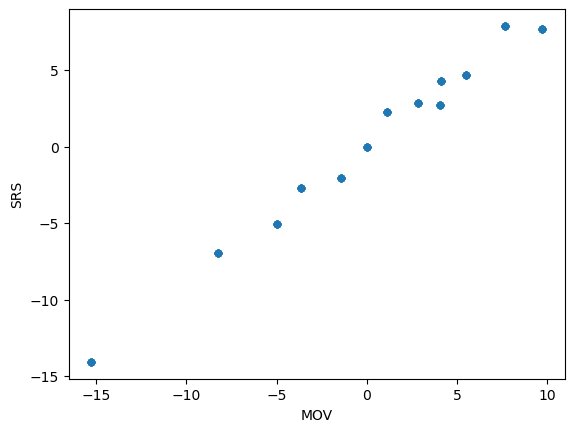

In [59]:
# inspect MOV and SRS
opp_team_df.plot.scatter(x='MOV', y='SRS')

In [60]:
# remove MOV due to its correlation with SRS
opp_team_df.drop(columns='MOV', inplace=True)

<Axes: xlabel='NRtg', ylabel='SRS'>

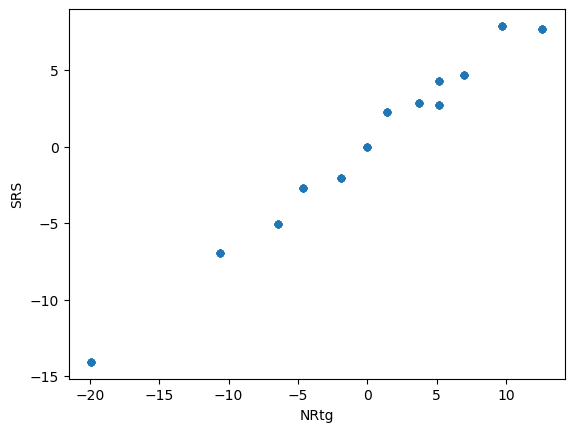

In [61]:
# inspect SRS vs NRtg
opp_team_df.plot.scatter(x='NRtg', y='SRS')

In [62]:
# remove SRS due to its correlation with NRtg
opp_team_df.drop(columns='SRS', inplace=True)

<Axes: xlabel='FG%', ylabel='TS%'>

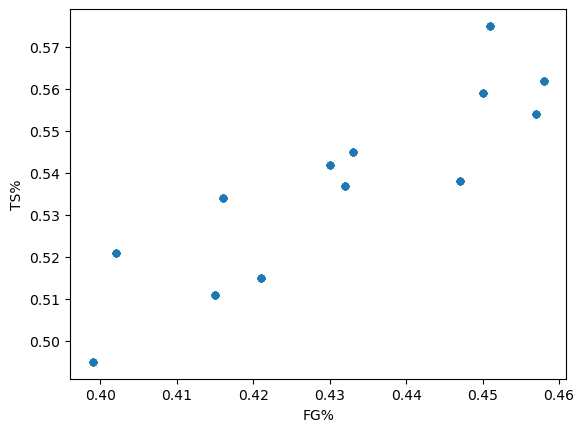

In [63]:
# inspect FG% vs TS%
opp_team_df.plot.scatter(x='FG%', y='TS%')

<Axes: xlabel='3P%', ylabel='TS%'>

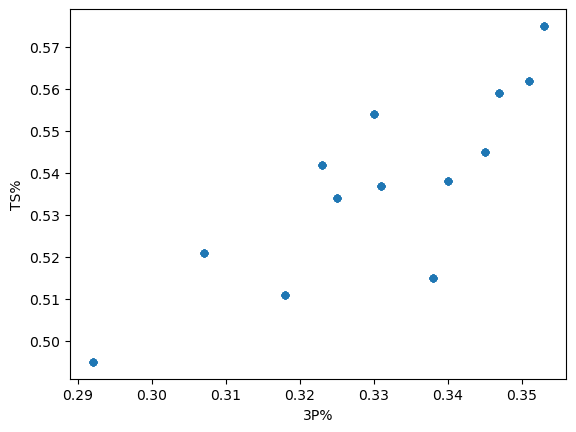

In [64]:
# inspect 3P% vs TS%
opp_team_df.plot.scatter(x='3P%', y='TS%')

<Axes: xlabel='3P%', ylabel='FG%'>

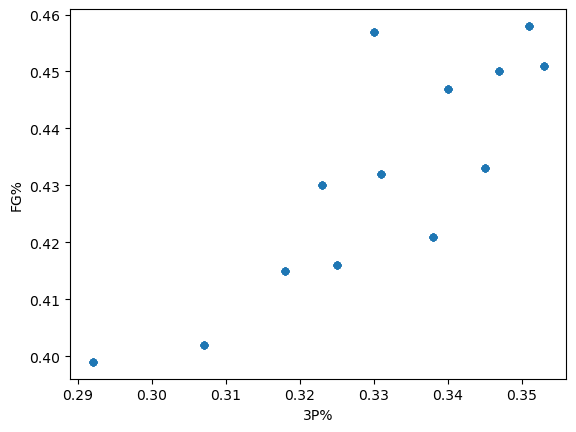

In [65]:
# inspect 3P% vs FG%
opp_team_df.plot.scatter(x='3P%', y='FG%')

In [66]:
# remove TS% due to its correlation with other variables
opp_team_df.drop(columns='TS%', inplace=True)

<Axes: xlabel='ORtg', ylabel='DRtg'>

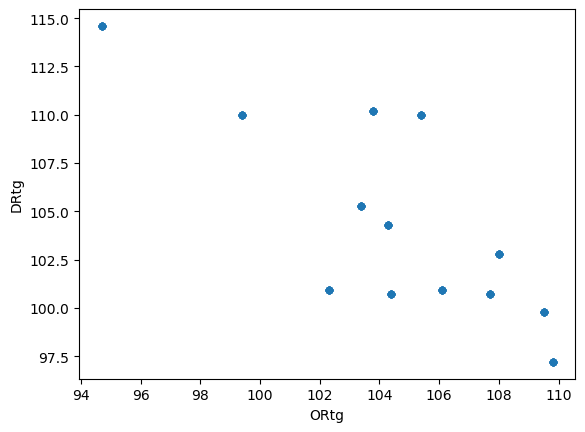

In [67]:
# inspect ORtg vs DRtg
opp_team_df.plot.scatter(x='ORtg', y='DRtg')

<Axes: xlabel='ORtg', ylabel='NRtg'>

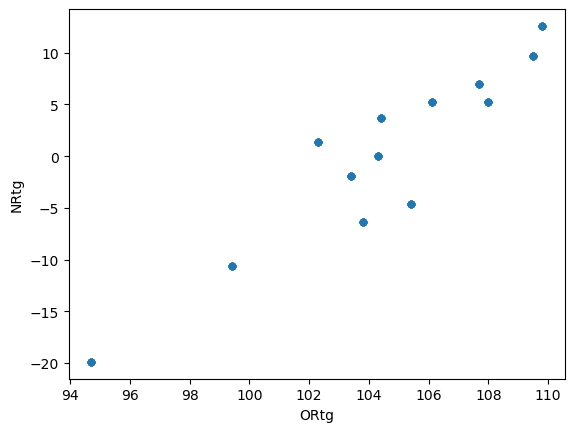

In [68]:
# inspect ORtg vs NRtg
opp_team_df.plot.scatter(x='ORtg', y='NRtg')

<Axes: xlabel='DRtg', ylabel='NRtg'>

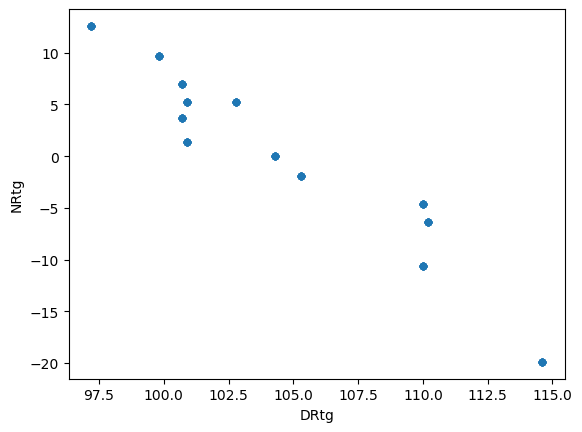

In [69]:
# inspect DRtg vs NRtg
opp_team_df.plot.scatter(x='DRtg', y='NRtg')

In [70]:
# remove DRtg and ORtg due to their correlation with other variables
opp_team_df.drop(columns=['DRtg', 'ORtg'], inplace=True)

We will view the data again, and make decisions from there

In [71]:
# view data again
opp_team_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 143 entries, 0 to 12
Data columns (total 31 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Team      143 non-null    object 
 1   FGA       143 non-null    float64
 2   FG%       143 non-null    float64
 3   3PA       143 non-null    float64
 4   3P%       143 non-null    float64
 5   2PA       143 non-null    float64
 6   2P%       143 non-null    float64
 7   FTA       143 non-null    float64
 8   FT%       143 non-null    float64
 9   ORB       143 non-null    float64
 10  DRB       143 non-null    float64
 11  AST       143 non-null    float64
 12  STL       143 non-null    float64
 13  BLK       143 non-null    float64
 14  TOV       143 non-null    float64
 15  PF        143 non-null    float64
 16  PTS       143 non-null    float64
 17  Age       143 non-null    float64
 18  NRtg      143 non-null    float64
 19  Pace      143 non-null    float64
 20  O-eFG%    143 non-null    float64
 21 

In [72]:
opp_team_df.columns

Index(['Team', 'FGA', 'FG%', '3PA', '3P%', '2PA', '2P%', 'FTA', 'FT%', 'ORB',
       'DRB', 'AST', 'STL', 'BLK', 'TOV', 'PF', 'PTS', 'Age', 'NRtg', 'Pace',
       'O-eFG%', 'O-TOV%', 'O-ORB%', 'O-FT/FGA', 'D-eFG%', 'D-TOV%', 'D-ORB%',
       'D-FT/FG', 'W/L%', 'GB', 'Year'],
      dtype='object')

We will inspect if there is more correlation between variables

<Axes: xlabel='FG%', ylabel='O-eFG%'>

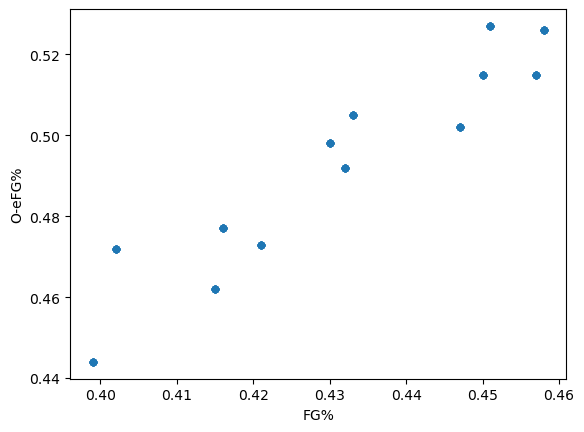

In [73]:
# inspect FG% vs O-eFG%
opp_team_df.plot.scatter(x='FG%', y='O-eFG%')

In [74]:
# remove O-eFG% due to its correlation with FG%
opp_team_df.drop(columns='O-eFG%', inplace=True)

In [75]:
# remove O-FT/FGA due bc it is already implied
opp_team_df.drop(columns='O-FT/FGA', inplace=True)

<Axes: xlabel='ORB', ylabel='O-ORB%'>

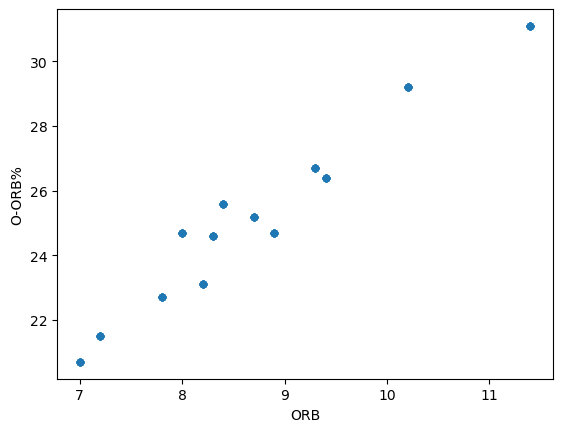

In [76]:
# inspect ORB vs O-ORB%
opp_team_df.plot.scatter(x='ORB', y='O-ORB%')

In [77]:
# remove O-ORB% due bc it is already implied
opp_team_df.drop(columns='O-ORB%', inplace=True)

<Axes: xlabel='TOV', ylabel='O-TOV%'>

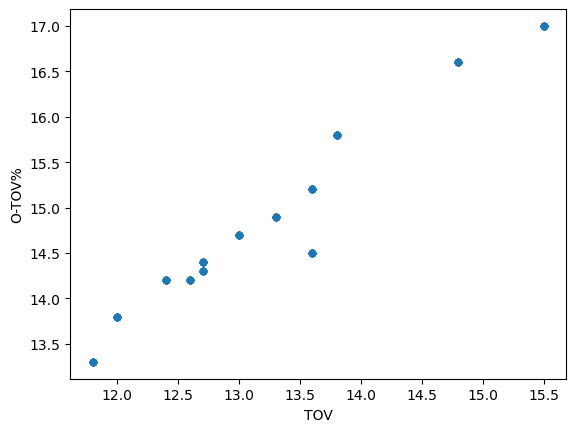

In [78]:
# inspect TOV vs O-TOV%
opp_team_df.plot.scatter(x='TOV', y='O-TOV%')

In [79]:
# remove O-TOV% due bc it is already implied
opp_team_df.drop(columns='O-TOV%', inplace=True)

<Axes: xlabel='DRB', ylabel='D-ORB%'>

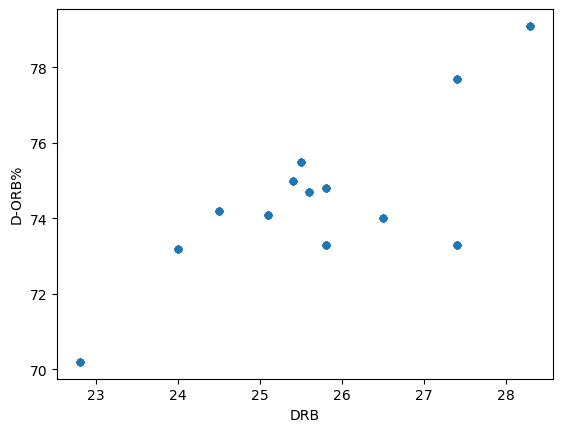

In [80]:
# inspect DRB vs D-ORB%
opp_team_df.plot.scatter(x='DRB', y='D-ORB%')

In [81]:
# remove D-ORB% due bc it is already implied
opp_team_df.drop(columns='D-ORB%', inplace=True)

In [82]:
opp_team_df.columns

Index(['Team', 'FGA', 'FG%', '3PA', '3P%', '2PA', '2P%', 'FTA', 'FT%', 'ORB',
       'DRB', 'AST', 'STL', 'BLK', 'TOV', 'PF', 'PTS', 'Age', 'NRtg', 'Pace',
       'D-eFG%', 'D-TOV%', 'D-FT/FG', 'W/L%', 'GB', 'Year'],
      dtype='object')

<Axes: xlabel='PF', ylabel='D-FT/FG'>

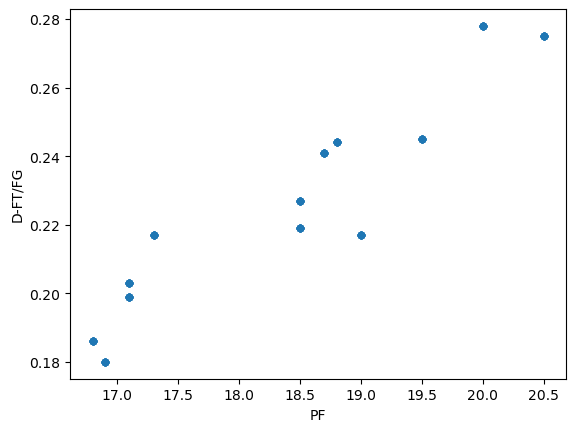

In [83]:
# inspect PF vs D-FT/FG
opp_team_df.plot.scatter(x='PF', y='D-FT/FG')

In [84]:
# remove D-FT/FG due bc it is already implied
opp_team_df.drop(columns='D-FT/FG', inplace=True)

<Axes: xlabel='STL', ylabel='D-TOV%'>

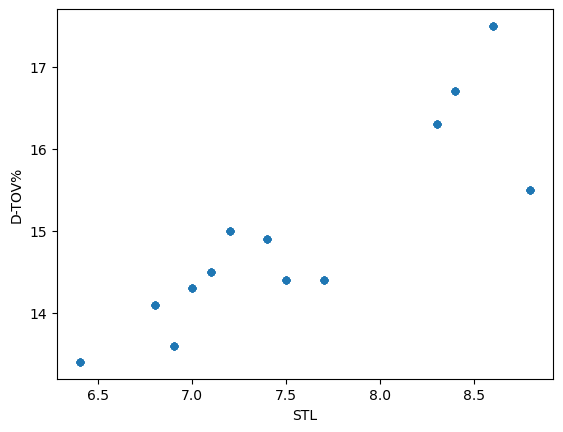

In [85]:
# inspect STL vs D-TOV%
opp_team_df.plot.scatter(x='STL', y='D-TOV%')

In [86]:
# remove STL due bc it is already implied
opp_team_df.drop(columns='STL', inplace=True)

In [87]:
# remove GB due bc it is already implied
opp_team_df.drop(columns='GB', inplace=True)

In [88]:
opp_team_df.columns

Index(['Team', 'FGA', 'FG%', '3PA', '3P%', '2PA', '2P%', 'FTA', 'FT%', 'ORB',
       'DRB', 'AST', 'BLK', 'TOV', 'PF', 'PTS', 'Age', 'NRtg', 'Pace',
       'D-eFG%', 'D-TOV%', 'W/L%', 'Year'],
      dtype='object')

<Axes: xlabel='BLK', ylabel='D-eFG%'>

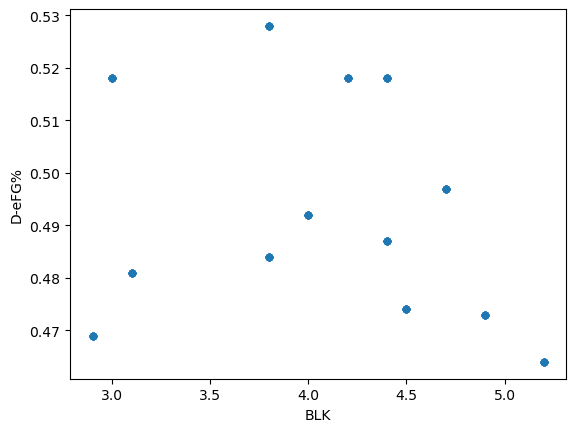

In [89]:
# inspect BLK vs D-eFG%, uncorrelated, so don't remove either
opp_team_df.plot.scatter(x='BLK', y='D-eFG%')

Next, we will look at the the distributions of all of the numerical data

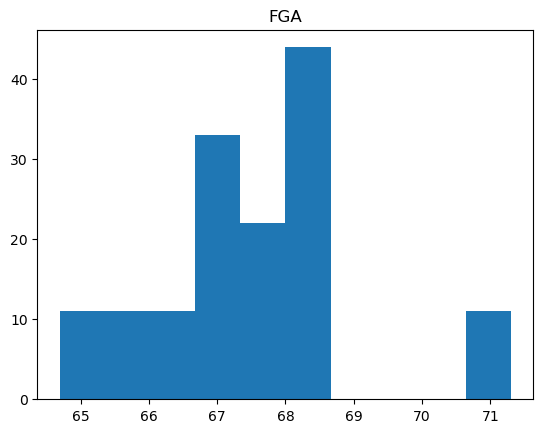

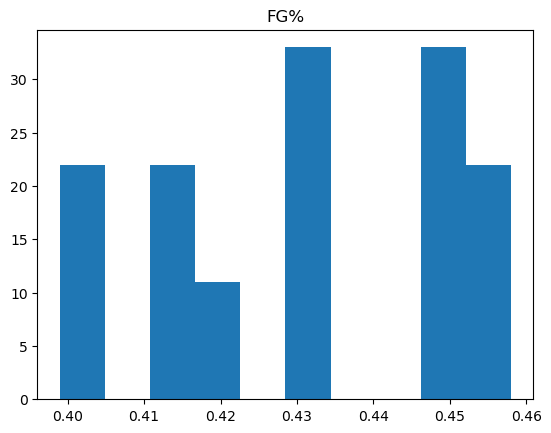

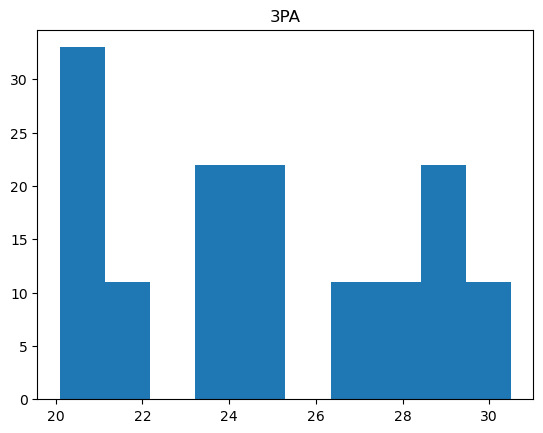

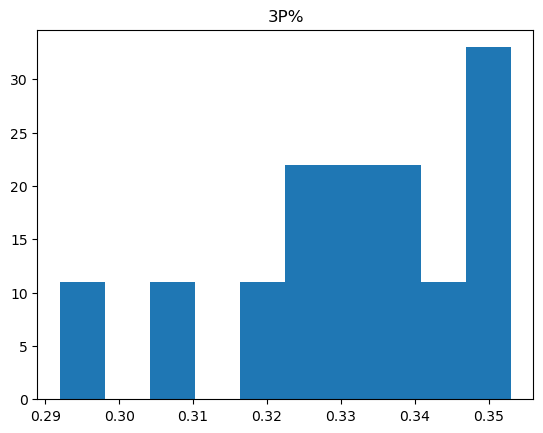

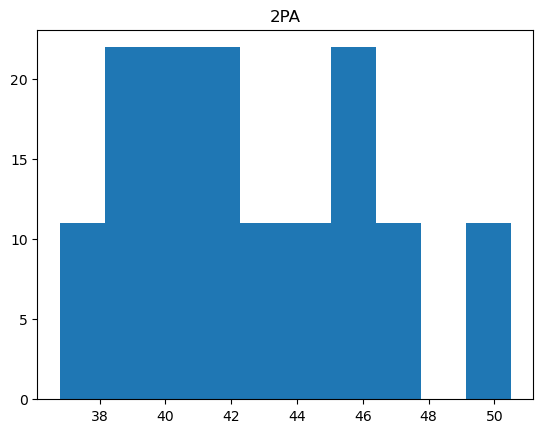

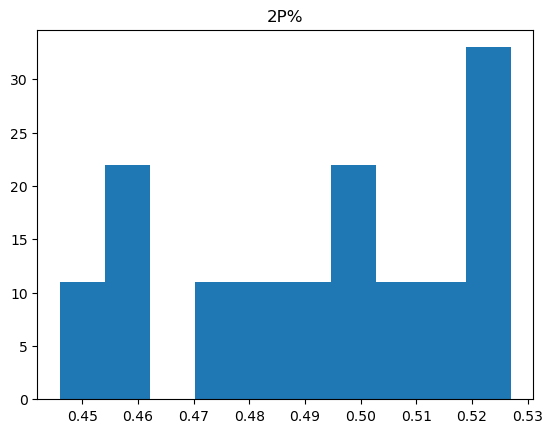

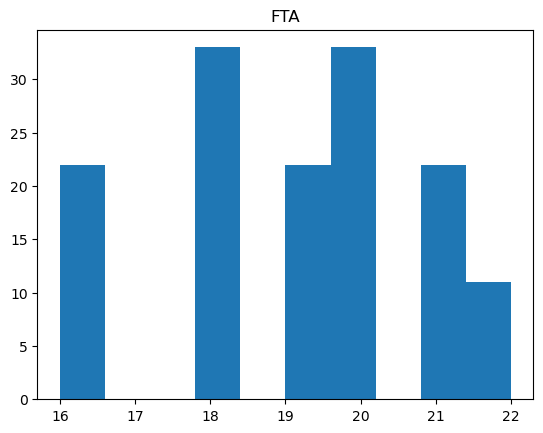

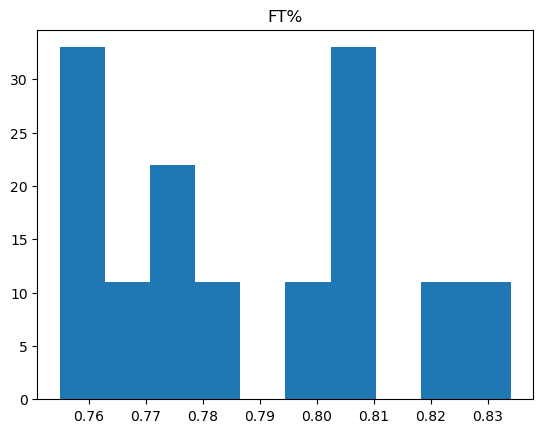

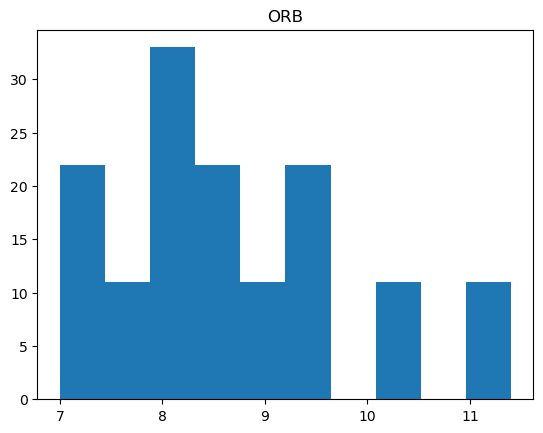

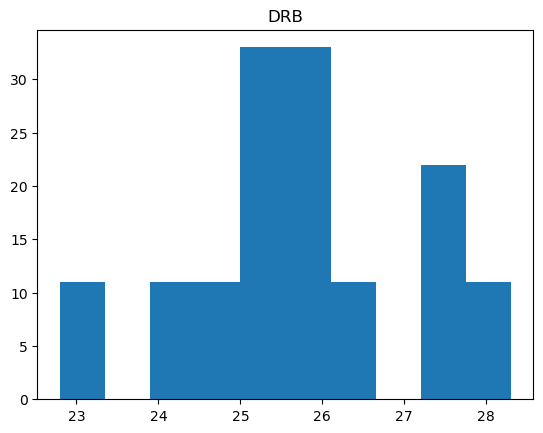

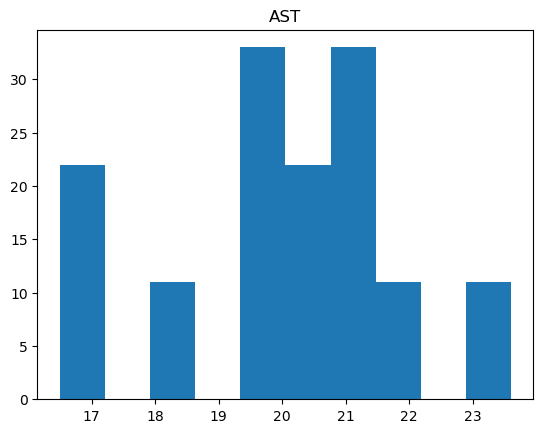

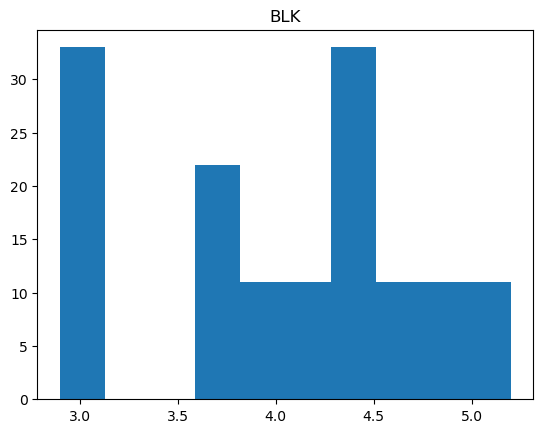

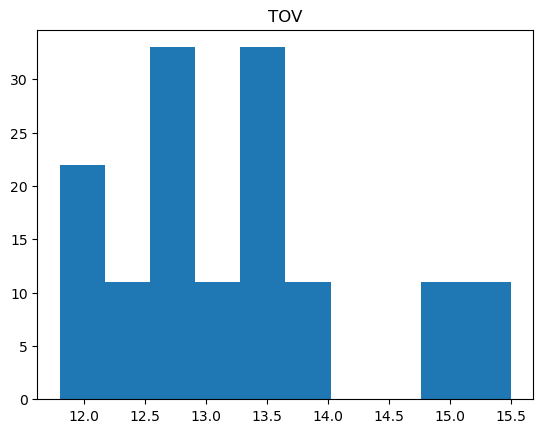

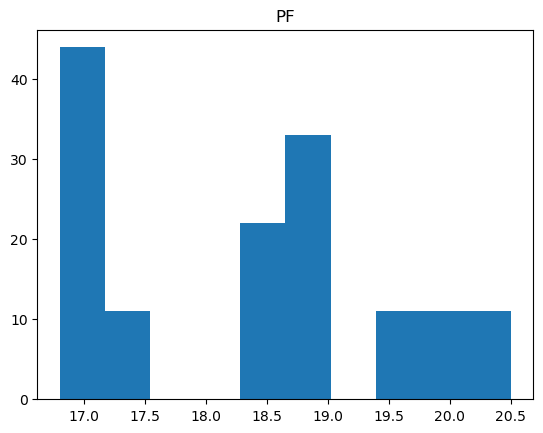

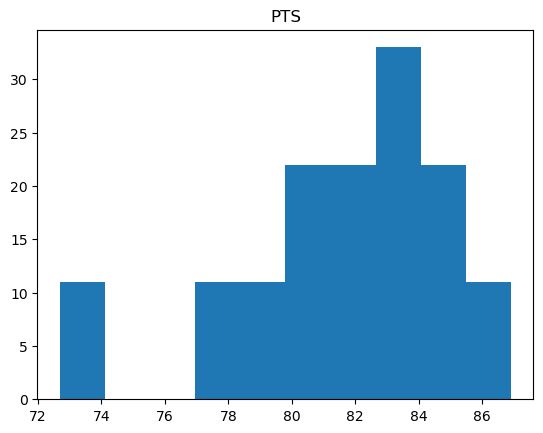

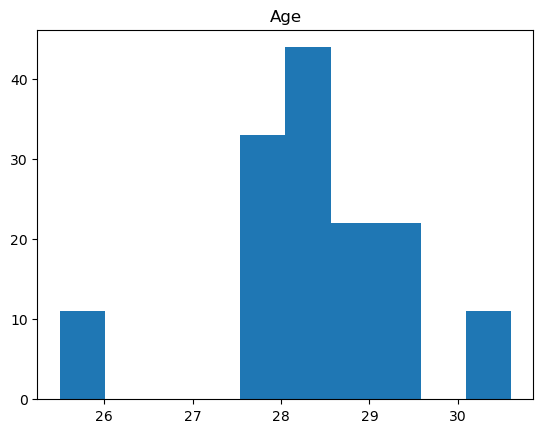

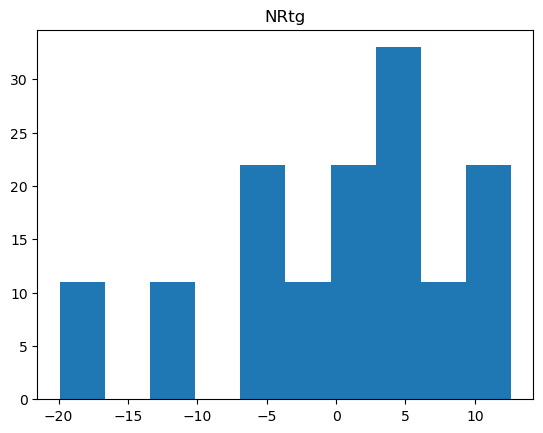

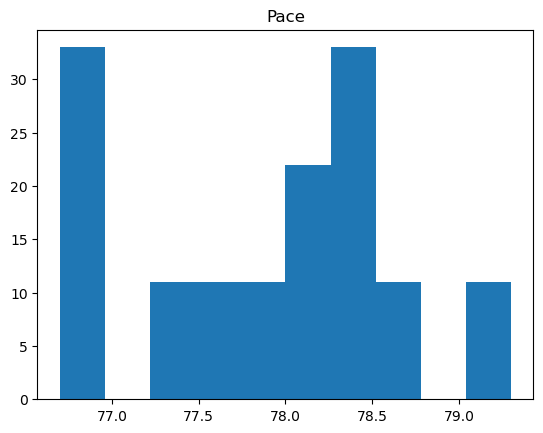

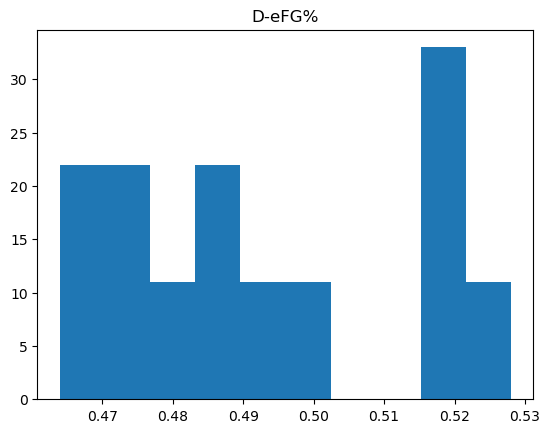

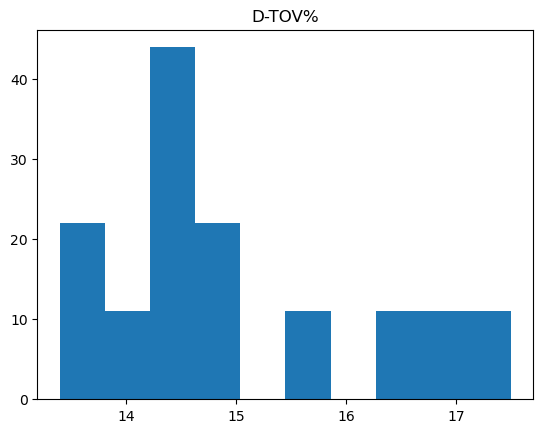

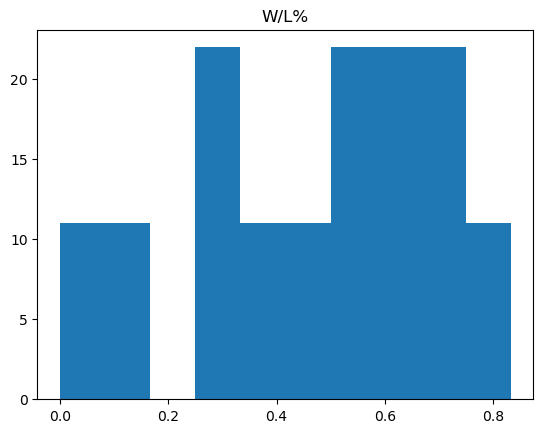

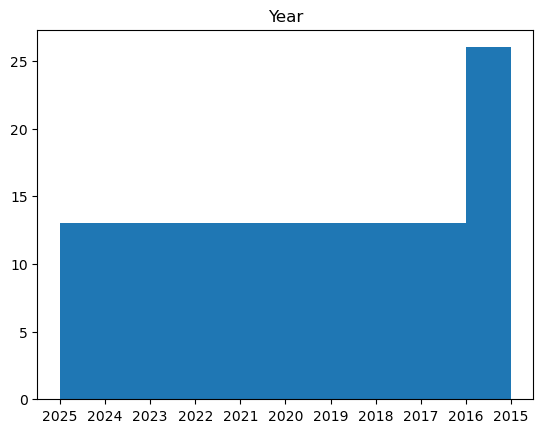

In [90]:
for i in opp_team_df.columns[1:]:
    plt.hist(opp_team_df[i])
    plt.title(i)
    plt.show()

We will also look at a heatmap to see if there are any more correlations

In [91]:
num_df = opp_team_df.iloc[:, 1:]

<Axes: >

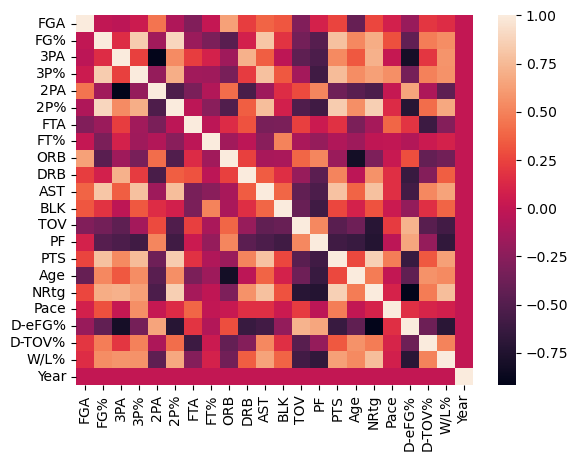

In [92]:
sns.heatmap(num_df.corr())

<Axes: xlabel='NRtg', ylabel='W/L%'>

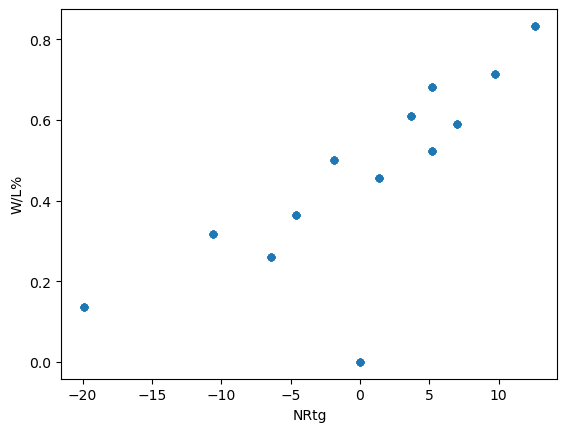

In [93]:
# inspect STL vs D-TOV%
opp_team_df.plot.scatter(x='NRtg', y='W/L%')

In [94]:
# remove W/L% due bc it is already implied
opp_team_df.drop(columns='W/L%', inplace=True)

### Next, we will look at categorical data from player_df dataset

In [95]:
player_df.head()

,Date,Opp,Location,PTS,AST,REB,Min,FGA,FG_pct
0,2025-05-16,LAS,Home,6,1,4,34:17,11,.273
1,2025-05-21,WAS,Home,18,1,5,26:52,14,.357
2,2025-05-23,LAS,Away,14,1,10,30:15,15,.267
3,2025-05-27,NYL,Away,13,0,6,28:22,10,.300
4,2025-05-29,NYL,Away,10,1,6,30:46,11,.364


In [96]:
player_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 296 entries, 0 to 295
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Date      296 non-null    object
 1   Opp       296 non-null    object
 2   Location  296 non-null    object
 3   PTS       296 non-null    object
 4   AST       296 non-null    object
 5   REB       296 non-null    object
 6   Min       296 non-null    object
 7   FGA       296 non-null    object
 8   FG_pct    292 non-null    object
dtypes: object(9)
memory usage: 20.9+ KB


First, we will change 'date' to 'month' and 'year' so that we have categories

In [97]:
dates = player_df.iloc[:, 0]
Month = []
for date in dates:
    m = date[5:7]
    Month.append(m)
    
player_df['Month'] = Month

In [98]:
dates = player_df.iloc[:, 0]
Year = []
for date in dates:
    y = date[:4]
    Year.append(y)
    
player_df['Year'] = Year

Now, we will change the data to the correct type

In [99]:
dtype_mapping = {
    'Date': str,
    'Opp': str, 
    'Location': str, 
    'Month': str,
    'Year': str,
    'PTS': int,
    'AST': int,
    'REB': int,
}

player_df = player_df.astype(dtype_mapping)

In [100]:
player_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 296 entries, 0 to 295
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Date      296 non-null    object
 1   Opp       296 non-null    object
 2   Location  296 non-null    object
 3   PTS       296 non-null    int32 
 4   AST       296 non-null    int32 
 5   REB       296 non-null    int32 
 6   Min       296 non-null    object
 7   FGA       296 non-null    object
 8   FG_pct    292 non-null    object
 9   Month     296 non-null    object
 10  Year      296 non-null    object
dtypes: int32(3), object(8)
memory usage: 22.1+ KB


### Combining the two dataframes

Next, we will combine the two datasets

In [101]:
# change 'Team' column to abbreviations to match the other dataframe
abbrev = {
    'New York Liberty': 'NYL',
    'Phoenix Mercury': 'PHO',
    'Minnesota Lynx': 'MIN',
    'Atlanta Dream': 'ATL',
    'Indiana Fever': 'IND',
    'Seattle Storm': 'SEA',
    'Los Angeles Sparks': 'LAS',
    'Dallas Wings': 'DAL',
    'Las Vegas Aces': 'LVA',
    'Golden State Valkyries': 'GSV',
    'Chicago Sky': 'CHI',
    'Washington Mystics': 'WAS',
    'Connecticut Sun': 'CON',
}

# Replace city names with abbreviations
opp_team_df['Team'] = opp_team_df['Team'].map(abbrev)

In [102]:
# Rename to match other dataframe
opp_team_df = opp_team_df.rename(columns={'Team': 'Opp'})

In [103]:
# merge dataframes
df = pd.merge(player_df, opp_team_df, on=['Opp', 'Year'], how='outer')

In [104]:
# view first row
df.iloc[0]

Date        2015-06-12
Opp                ATL
Location          Home
PTS_x              0.0
AST_x              0.0
REB                4.0
Min               8:20
FGA_x                4
FG_pct            .000
Month               06
Year              2015
FGA_y             68.0
FG%               0.43
3PA               28.8
3P%              0.323
2PA               39.2
2P%              0.508
FTA               21.1
FT%              0.757
ORB                9.3
DRB               28.3
AST_y             21.0
BLK                4.5
TOV               11.8
PF                17.1
PTS_y             83.8
Age               28.2
NRtg               7.0
Pace              77.3
D-eFG%           0.474
D-TOV%            13.4
Name: 0, dtype: object

In [105]:
# rename columns for clarity
df = df.rename(columns={'Opp': 'Opponent',
                        'PTS_x': 'Player_PTS',
                        'AST_x': 'Player_AST',
                        'REB': 'Player_REB',
                        'MIN': 'Player_Min',
                        'FGA_x': 'Player_FGA',
                        'FG_pct': 'Player_FG%',
                        'FGA_y': 'Opp_FGA',
                        'FG%': 'Opp_FG%',
                        '3PA': 'Opp_3PA',
                        '3P%': 'Opp_3P%',
                        '2PA': 'Opp_2PA',
                        '2P%': 'Opp_2P%',
                        'FTA': 'Opp_FTA',
                        'FT%': 'Opp_FT%',
                        'ORB': 'Opp_ORB',
                        'DRB': 'Opp_DRB',
                        'AST_y': 'Opp_AST',
                        'BLK': 'Opp_BLK',
                        'TOV': 'Opp_TOV',
                        'PF': 'Opp_PF',
                        'PTS_y': 'Opp_PTS',
                        'Age': 'Opp_Age',
                        'NRtg': 'Opp_NRtg',
                        'Pace': 'Opp_Pace',
                        'D-eFG%': 'Opp_D-eFG%',
                        'D-TOV%': 'Opp_D-TOV%'})

### Exploring how features affect labels

Now we will explore how our features affect the labels. We with points.

First, we will look at the the categorical features. We will look at bar charts to see how the categorical features affect points.

<BarContainer object of 2 artists>

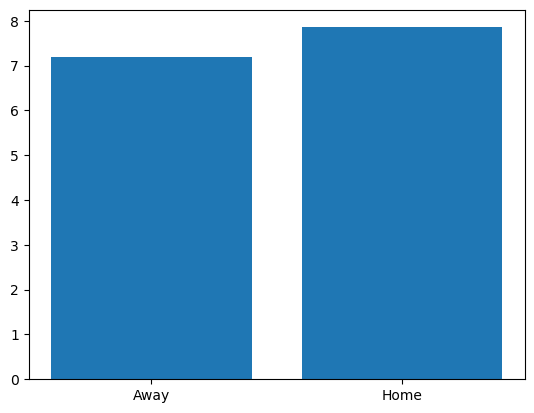

In [106]:
# Location vs PTS_x
location_points = df.groupby('Location')['Player_PTS'].mean()
plt.bar(location_points.index, location_points.values)

<BarContainer object of 15 artists>

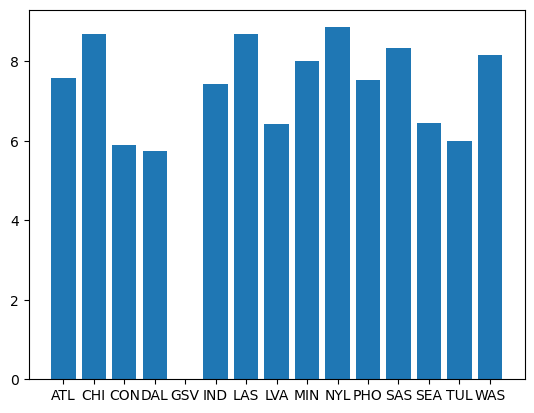

In [107]:
# Opp vs PTS_x
opp_points = df.groupby('Opponent')['Player_PTS'].mean()
plt.bar(opp_points.index, opp_points.values)

<BarContainer object of 5 artists>

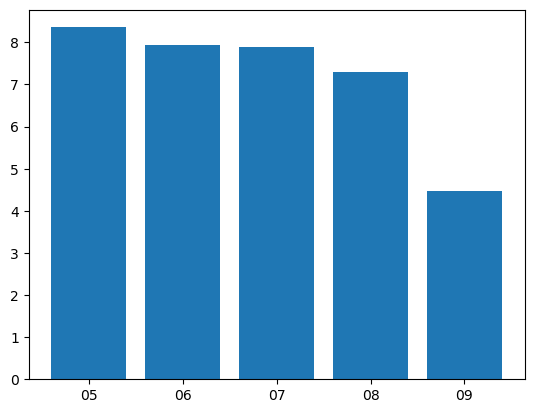

In [108]:
# Month vs PTS_x
month_points = df.groupby('Month')['Player_PTS'].mean()
plt.bar(month_points.index, month_points.values)

<BarContainer object of 11 artists>

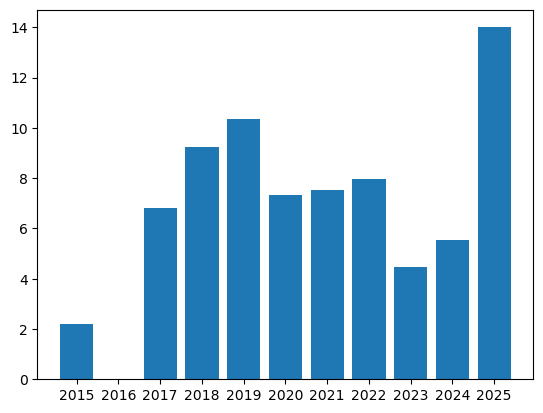

In [109]:
# Year vs PTS_x
year_points = df.groupby('Year')['Player_PTS'].mean()
plt.bar(year_points.index, year_points.values)

Now, we will look at the the numerical features using scatterplots

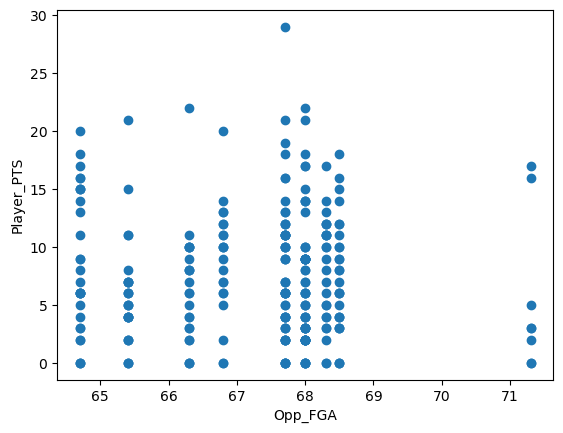

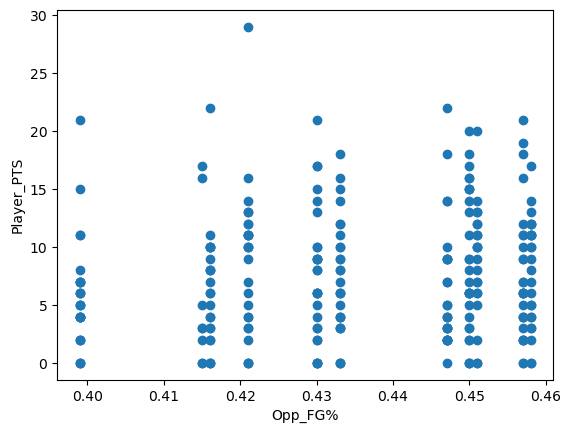

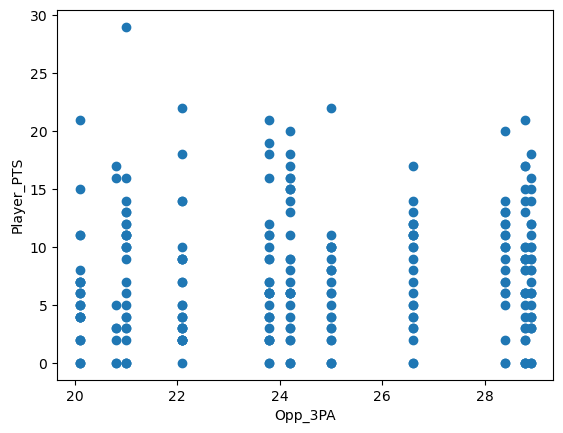

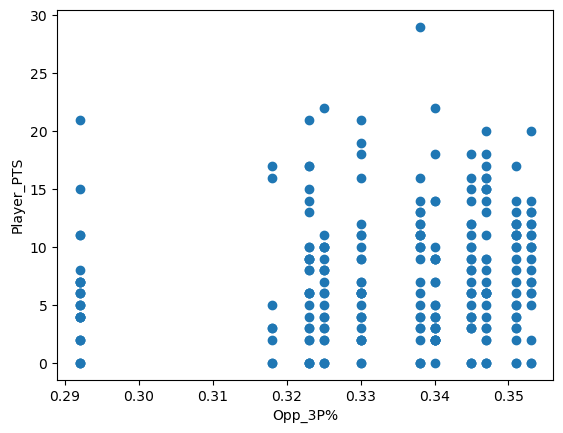

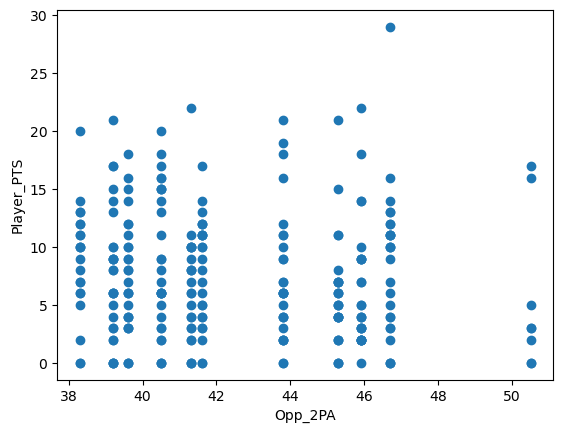

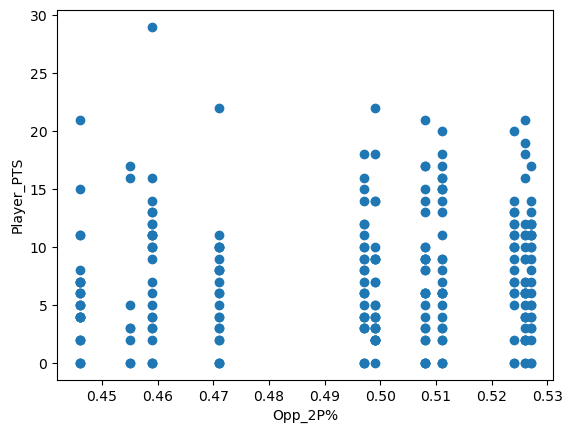

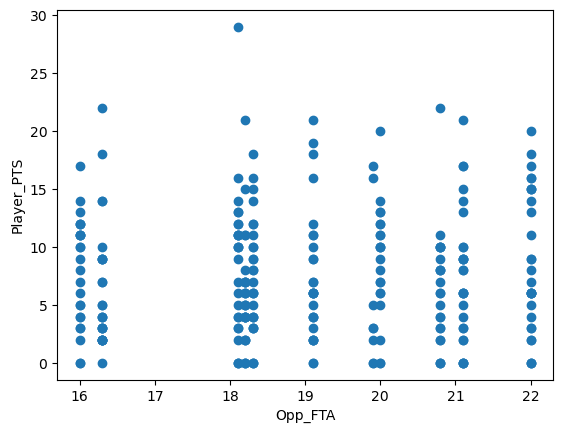

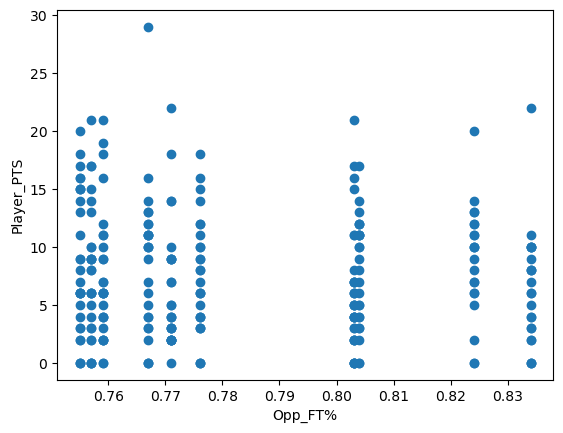

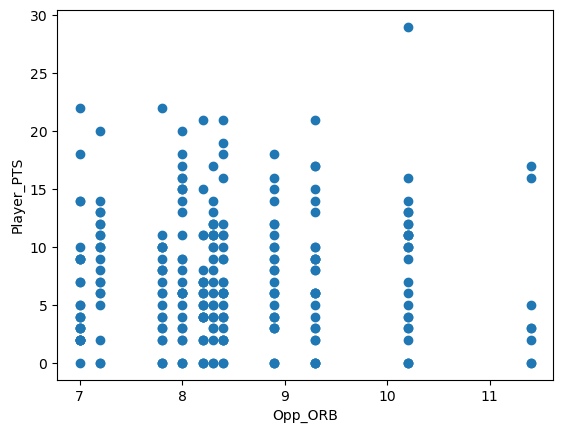

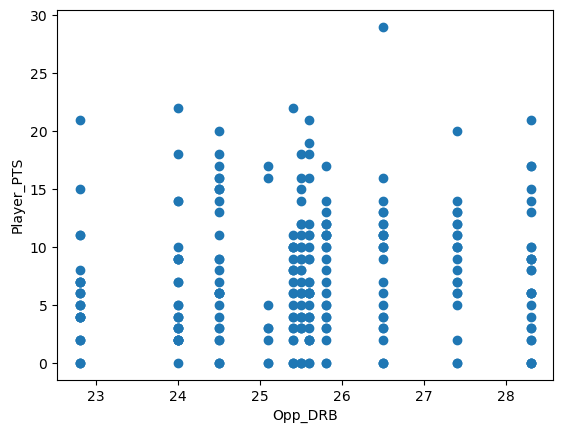

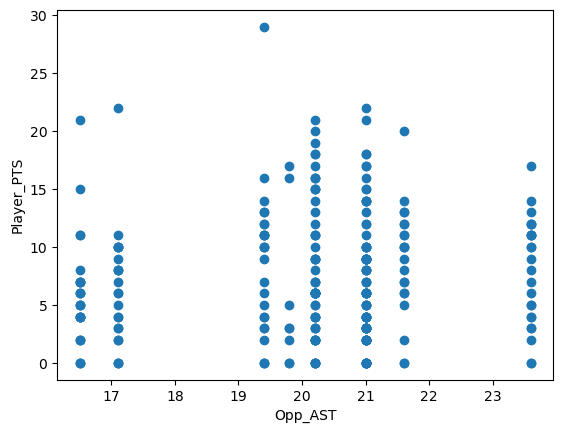

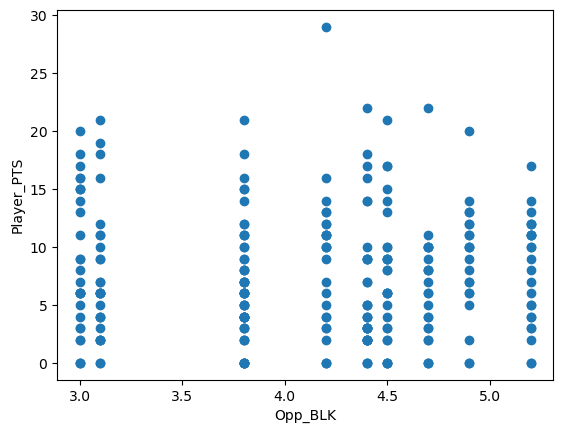

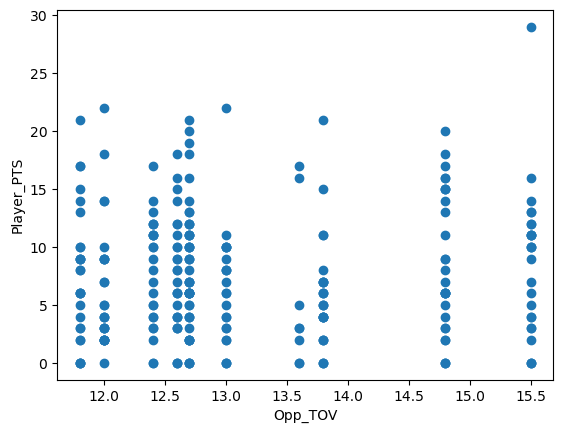

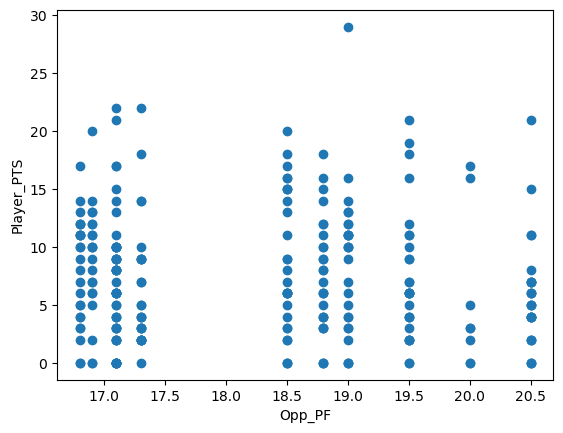

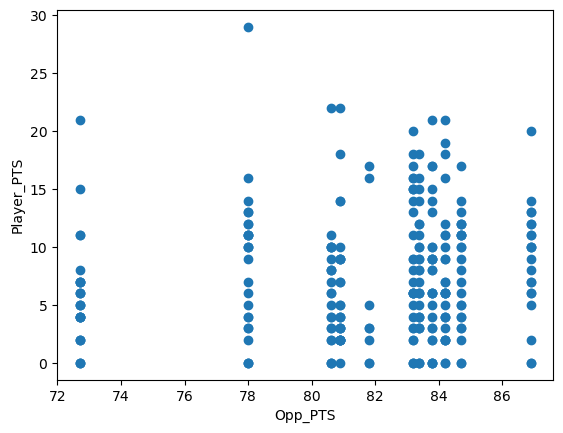

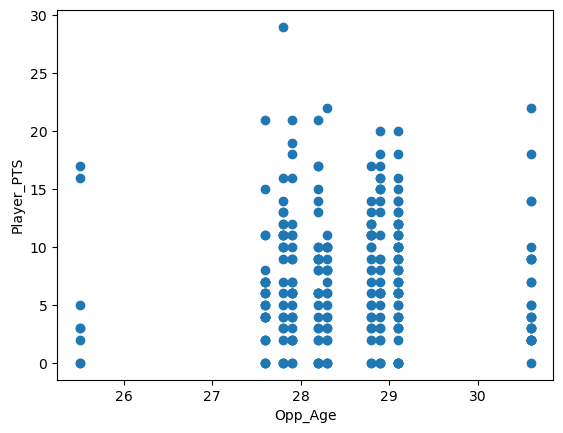

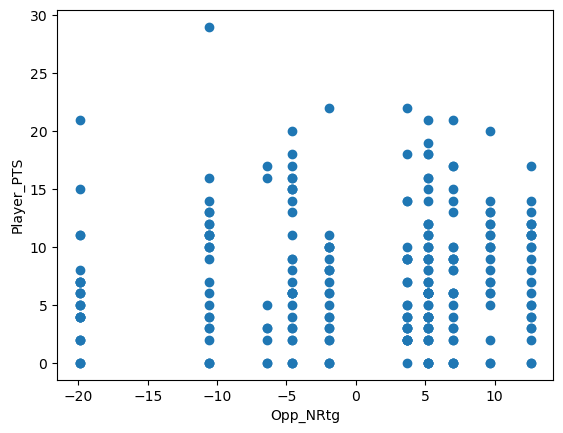

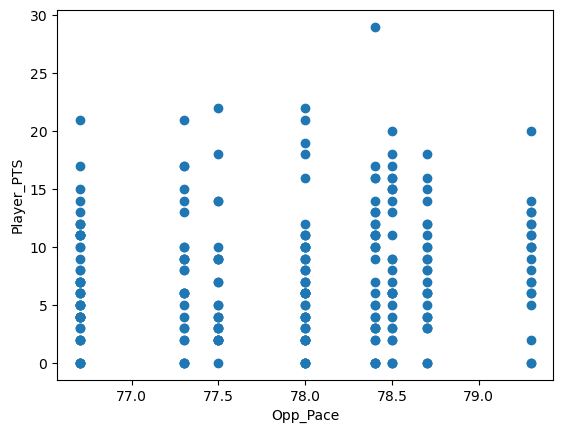

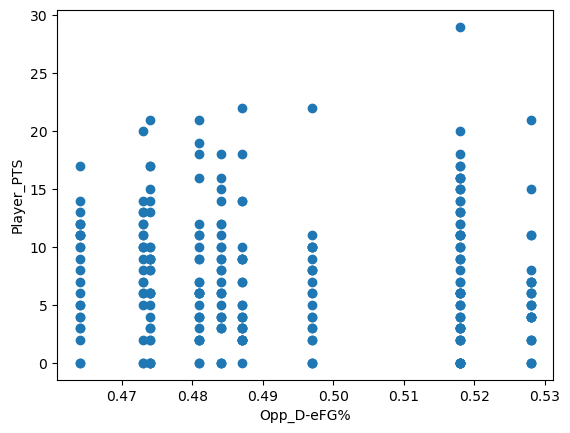

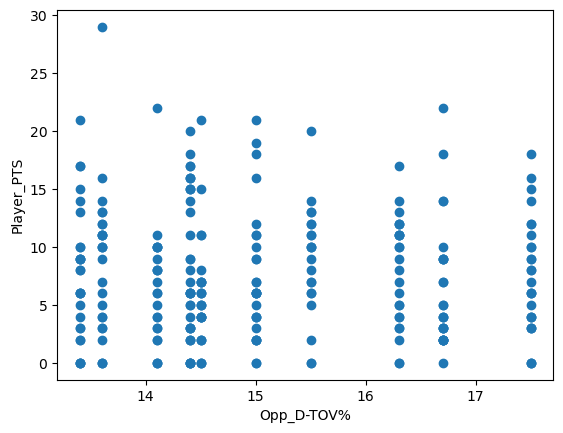

In [110]:
for i in df.columns[11:]:
    plt.scatter(df[i], df['Player_PTS'])
    plt.xlabel(i)
    plt.ylabel('Player_PTS')
    plt.show()

In [111]:
title_list = []
corr_list = []
for i in df.columns[11:]:
    corr = df[i].corr(df['Player_PTS'])
    corr_list.append(corr)
    title = i + ', Player_PTS'
    title_list.append(title)
    
corr_df = pd.DataFrame()
corr_df['Features'] = title_list
corr_df['Corr'] = corr_list
corr_df

,Features,Corr
0,"Opp_FGA, Player_PTS",-0.024102
1,"Opp_FG%, Player_PTS",0.099845
2,"Opp_3PA, Player_PTS",0.072601
3,"Opp_3P%, Player_PTS",0.136454
4,"Opp_2PA, Player_PTS",-0.083969
5,"Opp_2P%, Player_PTS",0.093342
6,"Opp_FTA, Player_PTS",0.045518
7,"Opp_FT%, Player_PTS",-0.053892
8,"Opp_ORB, Player_PTS",0.020070
9,"Opp_DRB, Player_PTS",0.103504


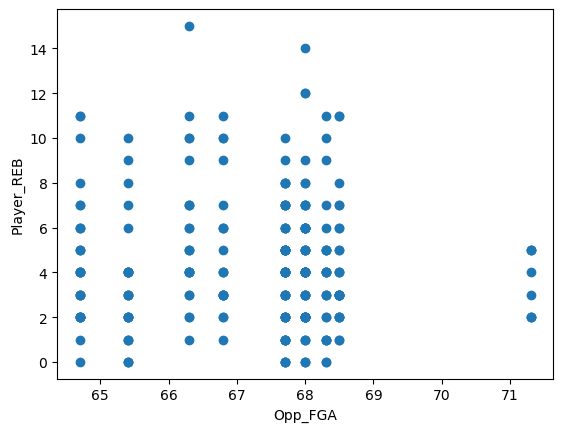

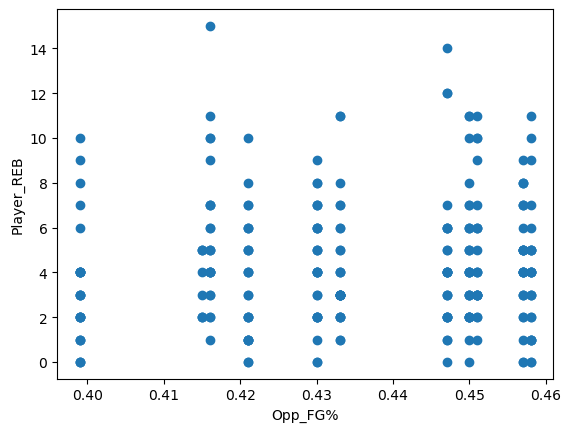

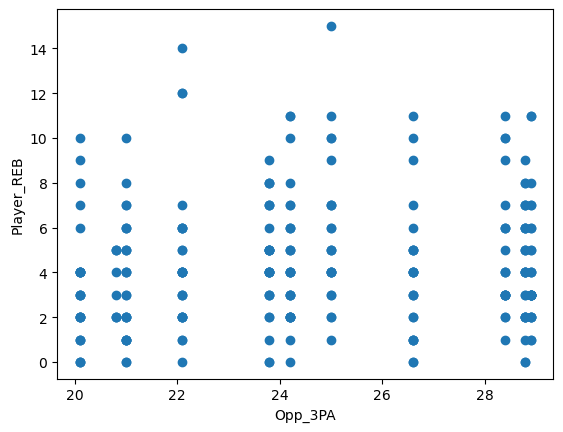

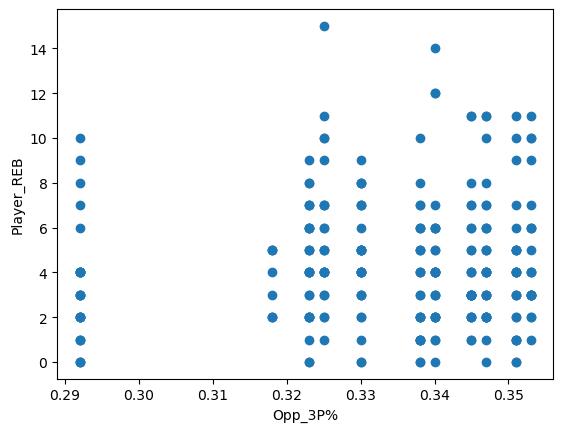

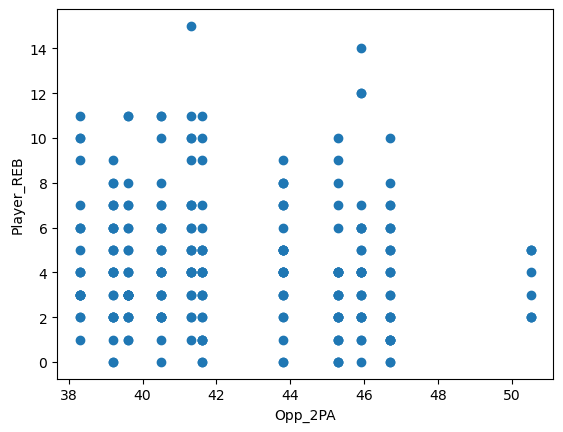

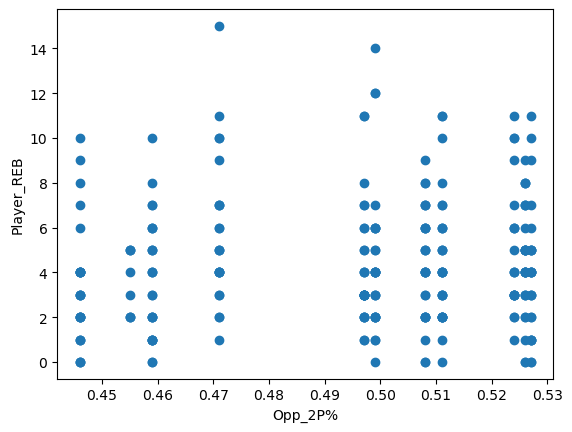

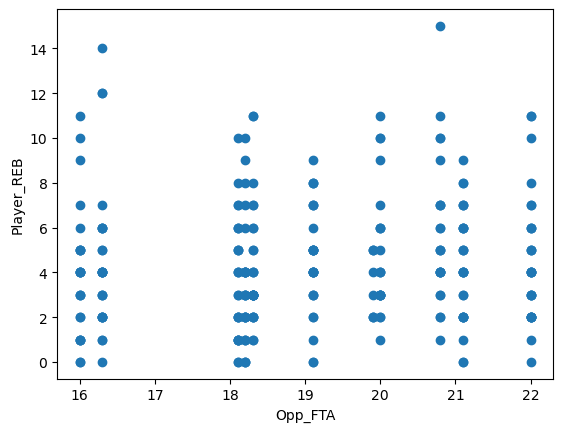

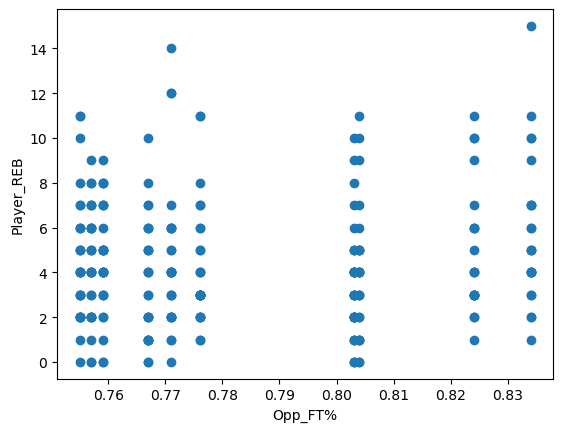

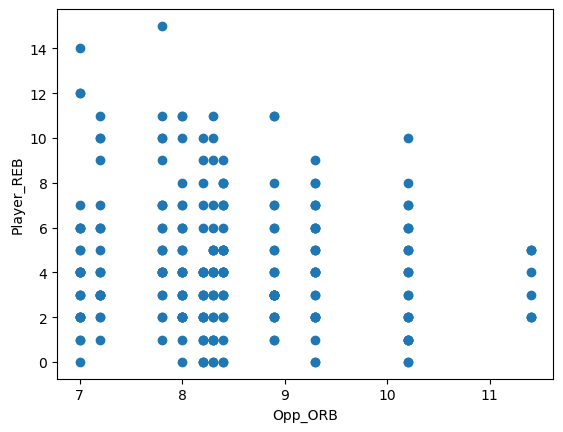

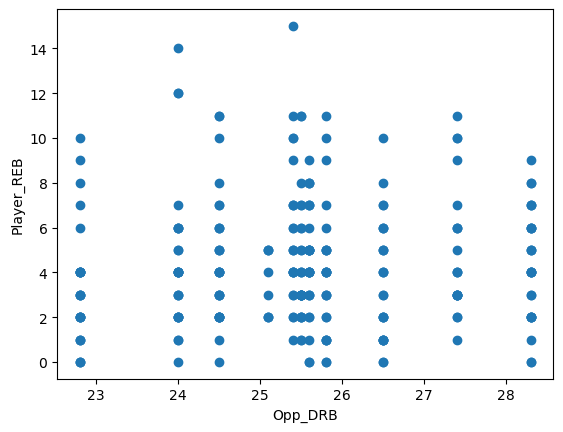

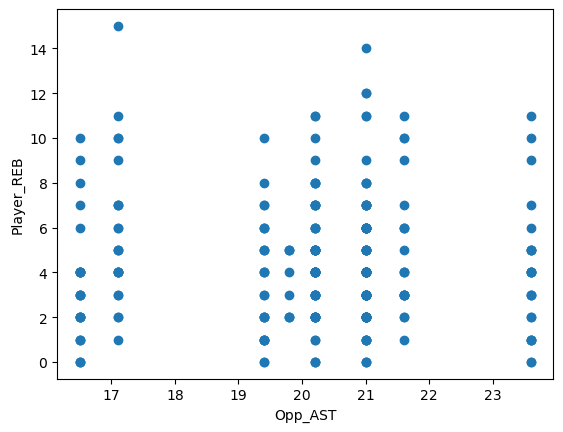

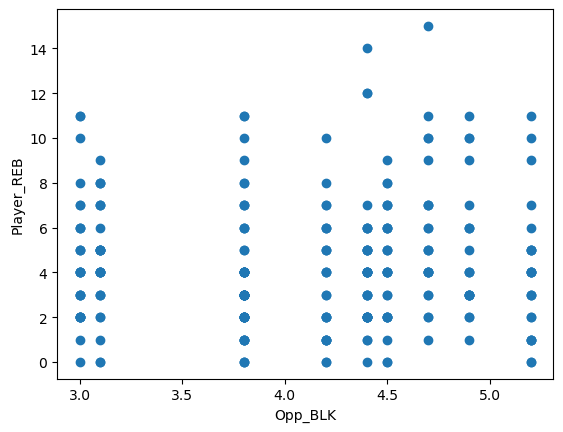

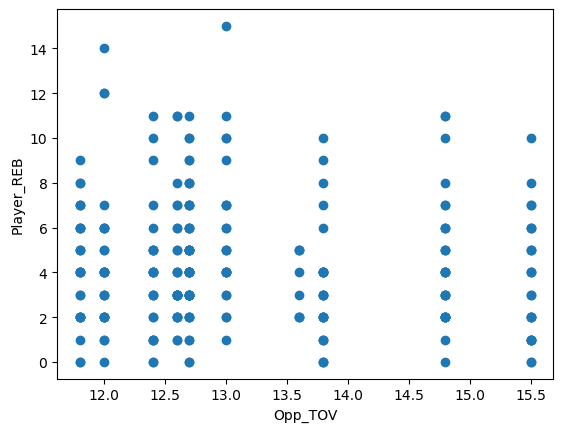

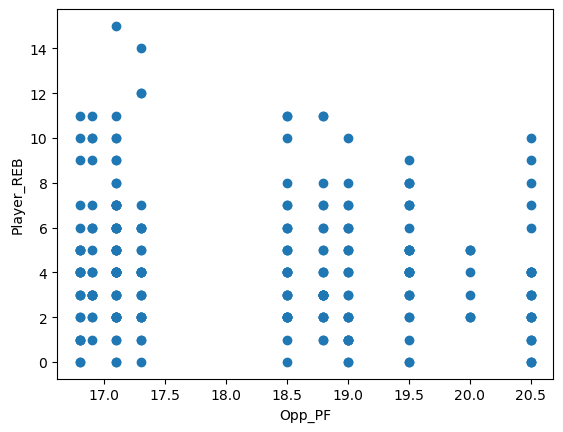

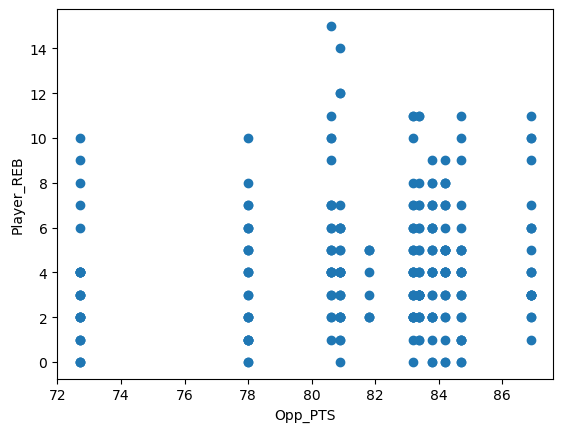

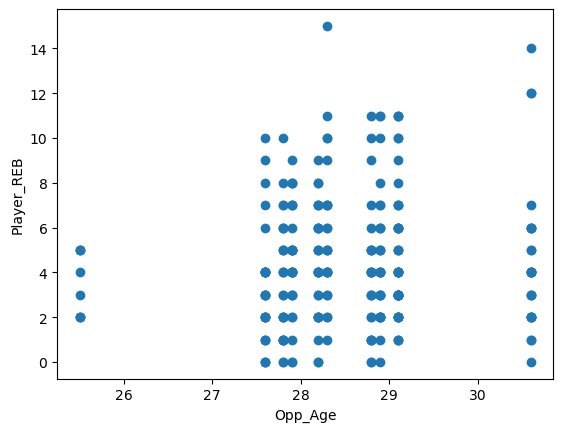

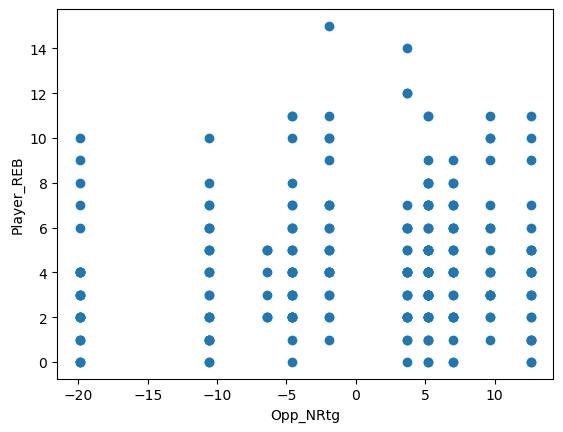

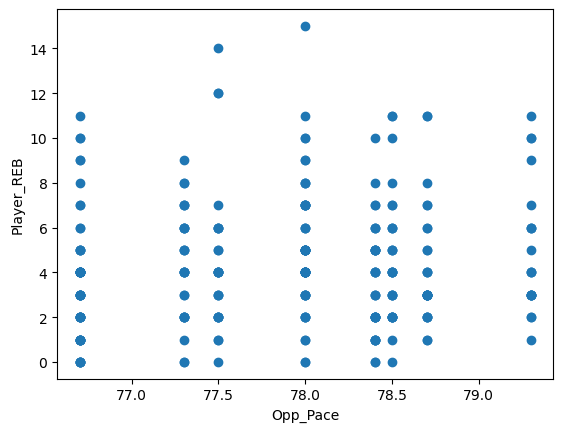

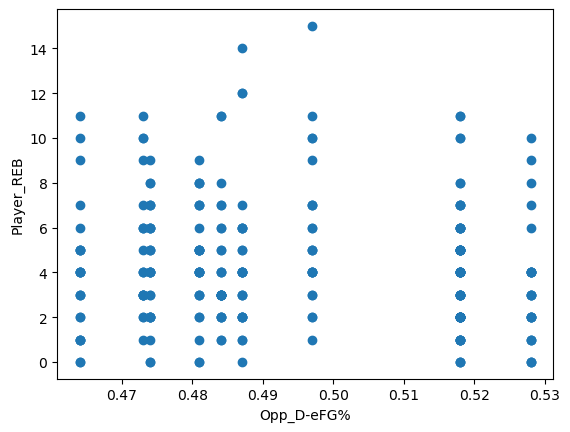

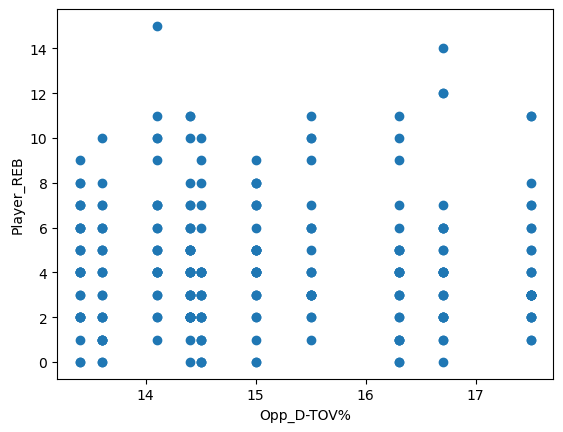

In [112]:
for i in df.columns[11:]:
    plt.scatter(df[i], df['Player_REB'])
    plt.xlabel(i)
    plt.ylabel('Player_REB')
    plt.show()

In [113]:
title_list = []
corr_list = []
for i in df.columns[11:]:
    corr = df[i].corr(df['Player_REB'])
    corr_list.append(corr)
    title = i + ', Player_REB'
    title_list.append(title)
    
corr_df = pd.DataFrame()
corr_df['Features'] = title_list
corr_df['Corr'] = corr_list
corr_df

,Features,Corr
0,"Opp_FGA, Player_REB",-0.044997
1,"Opp_FG%, Player_REB",0.064951
2,"Opp_3PA, Player_REB",0.089668
3,"Opp_3P%, Player_REB",0.071517
4,"Opp_2PA, Player_REB",-0.109975
5,"Opp_2P%, Player_REB",0.080162
6,"Opp_FTA, Player_REB",0.092356
7,"Opp_FT%, Player_REB",0.068782
8,"Opp_ORB, Player_REB",-0.122721
9,"Opp_DRB, Player_REB",0.049245


### Feature Engineering

We will engineer new features which may help with prediction

In [185]:
df.head()

,Date,Opponent,Location,Player_PTS,Player_AST,Player_REB,Min,Player_FGA,Player_FG%,Month,...,REB_Roll15,Min_Roll15,FGA_Roll15,FGP_Roll15,PTS_Roll20,AST_Roll20,REB_Roll20,Min_Roll20,FGA_Roll20,FGP_Roll20
0,2015-06-05,CON,Away,6.0,1.0,0.0,11:59,4,.750,06,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2015-06-06,NYL,Home,6.0,0.0,3.0,14:42,6,.500,06,...,0.000000,11.983333,4.000000,0.750000,6.0,1.000000,0.000000,11.983333,4.000000,0.750000
2,2015-06-12,ATL,Home,0.0,0.0,4.0,8:20,4,.000,06,...,1.500000,13.341667,5.000000,0.625000,6.0,0.500000,1.500000,13.341667,5.000000,0.625000
3,2015-06-14,NYL,Away,0.0,0.0,2.0,7:02,1,.000,06,...,2.333333,11.672222,4.666667,0.416667,4.0,0.333333,2.333333,11.672222,4.666667,0.416667
4,2015-06-19,TUL,Home,6.0,0.0,1.0,5:13,2,1.000,06,...,2.250000,10.512500,3.750000,0.312500,3.0,0.250000,2.250000,10.512500,3.750000,0.312500


The first feature we will engineer is days since last game.

In [115]:
# convert 'Date' column to datetime
df['Date'] = pd.to_datetime(df['Date'])

# sort by date
df = df.sort_values('Date').reset_index(drop=True)

# compute difference in days between consecutive games
df['DaysSinceLastGame'] = df['Date'].diff().dt.days

# Mark back-to-back games (1 day apart)
df['BackToBack'] = df['DaysSinceLastGame'] == 1

# Convert to int (1 for True, 0 for False)
df['BackToBack'] = df['BackToBack'].astype(int)

In [116]:
# Create the categorical column
def categorize_days(x):
    if pd.isna(x):
        return '0'       # First game (no prior)
    elif x >= 5:
        return '5+'
    else:
        return str(int(x))  # '1' to '4'

df['DaysSinceLastGame'] = df['Date'].diff().dt.days
df['DaysSinceLastGame_Cat'] = df['DaysSinceLastGame'].apply(categorize_days)

<BarContainer object of 6 artists>

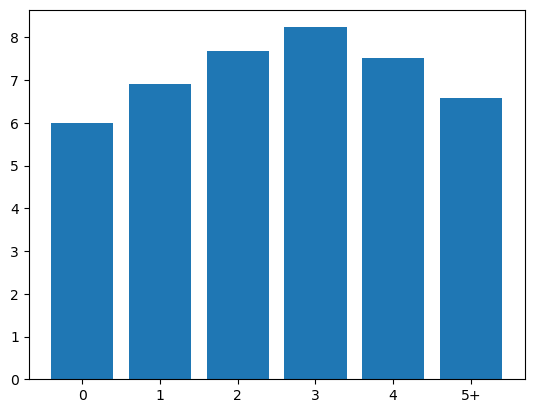

In [117]:
# DaySinceLastGame vs PTS_x
days_points = df.groupby('DaysSinceLastGame_Cat')['Player_PTS'].mean()
plt.bar(days_points.index, days_points.values)

<BarContainer object of 2 artists>

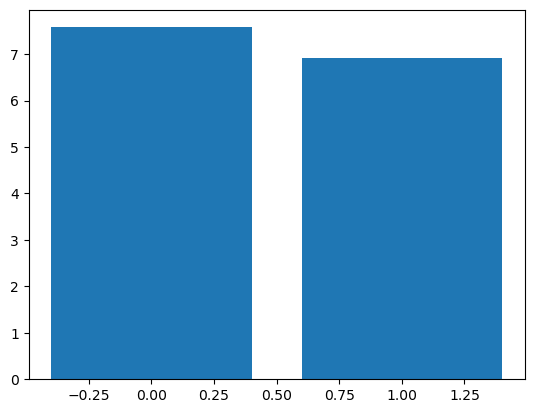

In [118]:
# BackToBack vs PTS_x
backtoback_points = df.groupby('BackToBack')['Player_PTS'].mean()
plt.bar(backtoback_points.index, backtoback_points.values)

Next, we will engineer rolling stats based on the past 5 games.

In [119]:
df.head()

,Date,Opponent,Location,Player_PTS,Player_AST,Player_REB,Min,Player_FGA,Player_FG%,Month,...,Opp_PF,Opp_PTS,Opp_Age,Opp_NRtg,Opp_Pace,Opp_D-eFG%,Opp_D-TOV%,DaysSinceLastGame,BackToBack,DaysSinceLastGame_Cat
0,2015-06-05,CON,Away,6.0,1.0,0.0,11:59,4,.750,06,...,20.5,72.7,27.6,-19.9,76.7,0.528,14.5,NaN,0,0
1,2015-06-06,NYL,Home,6.0,0.0,3.0,14:42,6,.500,06,...,16.9,86.9,29.1,9.7,79.3,0.473,15.5,1.0,1,1
2,2015-06-12,ATL,Home,0.0,0.0,4.0,8:20,4,.000,06,...,17.1,83.8,28.2,7.0,77.3,0.474,13.4,6.0,0,5+
3,2015-06-14,NYL,Away,0.0,0.0,2.0,7:02,1,.000,06,...,16.9,86.9,29.1,9.7,79.3,0.473,15.5,2.0,0,2
4,2015-06-19,TUL,Home,6.0,0.0,1.0,5:13,2,1.000,06,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.0,0,5+


In [120]:
def convert_min_to_float(min_str):
    try:
        if pd.isna(min_str):
            return np.nan
        minutes, seconds = map(int, min_str.split(':'))
        return minutes + seconds / 60
    except:
        return np.nan

df['Min_float'] = df['Min'].apply(convert_min_to_float)


# Define columns to roll
rolling_cols = {
    'Player_PTS': 'PTS_Roll5',
    'Player_AST': 'AST_Roll5',
    'Player_REB': 'REB_Roll5',
    'Min_float': 'Min_Roll5',
    'Player_FGA': 'FGA_Roll5',
    'Player_FG%': 'FGP_Roll5'
}

# Apply 5-game rolling average (excluding current game)
for col, new_col in rolling_cols.items():
    df[new_col] = df[col].shift(1).rolling(window=5, min_periods=1).mean()

Now we will engineer exanding averages

In [121]:
df['PTS_ExpAvg'] = df['Player_PTS'].expanding().mean().shift(1)
df['AST_ExpAvg'] = df['Player_AST'].expanding().mean().shift(1)
df['REB_ExpAvg'] = df['Player_REB'].expanding().mean().shift(1)
df['Min_ExpAvg'] = df['Min_float'].expanding().mean().shift(1)
df['FGA_ExpAvg'] = df['Player_FGA'].expanding().mean().shift(1)
df['FG%_ExpAvg'] = df['Player_FG%'].expanding().mean().shift(1)

Finally, we will clean the data once again.

In [122]:
df.dropna(subset=["Location"], inplace=True)

### Model Building

Now, we will begin to build our models

In [123]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 296 entries, 0 to 295
Data columns (total 47 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   Date                   296 non-null    datetime64[ns]
 1   Opponent               296 non-null    object        
 2   Location               296 non-null    object        
 3   Player_PTS             296 non-null    float64       
 4   Player_AST             296 non-null    float64       
 5   Player_REB             296 non-null    float64       
 6   Min                    296 non-null    object        
 7   Player_FGA             296 non-null    object        
 8   Player_FG%             292 non-null    object        
 9   Month                  296 non-null    object        
 10  Year                   296 non-null    object        
 11  Opp_FGA                268 non-null    float64       
 12  Opp_FG%                268 non-null    float64       
 13  Opp_3PA   

In [124]:
# view correlations again
title_list = []
corr_list = []
for i in df.iloc[:, list(range(11, 31)) + list(range(34, 47))]:
    corr = df[i].corr(df['Player_PTS'])
    corr_list.append(corr)
    title = i + ', Player_PTS'
    title_list.append(title)
    
corr_df = pd.DataFrame()
corr_df['Features'] = title_list
corr_df['Corr'] = corr_list
corr_df

,Features,Corr
0,"Opp_FGA, Player_PTS",-0.024102
1,"Opp_FG%, Player_PTS",0.099845
2,"Opp_3PA, Player_PTS",0.072601
3,"Opp_3P%, Player_PTS",0.136454
4,"Opp_2PA, Player_PTS",-0.083969
5,"Opp_2P%, Player_PTS",0.093342
6,"Opp_FTA, Player_PTS",0.045518
7,"Opp_FT%, Player_PTS",-0.053892
8,"Opp_ORB, Player_PTS",0.020070
9,"Opp_DRB, Player_PTS",0.103504


In [137]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

First model (regression)

In [126]:
# Define features and target
categorical_features = ['Location', 'Year']
numeric_features = ['PTS_Roll5', 'AST_Roll5', 'REB_Roll5', 'Min_Roll5', 'Opp_D-eFG%']
target = 'Player_PTS'

# Drop rows with missing data in selected columns
df_model = df[categorical_features + numeric_features + [target]].dropna()

X = df_model[categorical_features + numeric_features]
y = df_model[target]

In [127]:
# One-hot encode categorical features
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first'), categorical_features)
    ],
    remainder='passthrough'  # Pass numeric features unchanged
)

In [128]:
# Split into train/test sets (80/20 split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Build model pipeline with preprocessing + Random Forest
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(n_estimators=100, random_state=42))
])

# Train the model
model.fit(X_train, y_train)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat',
                                                  OneHotEncoder(drop='first'),
                                                  ['Location', 'Year'])])),
                ('regressor', RandomForestRegressor(random_state=42))])

In [129]:
# Predict on test set
y_pred = model.predict(X_test)

# Evaluate performance
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"Test RMSE: {rmse:.2f}")
print(f"Test R² Score: {r2:.2f}")

Test RMSE: 5.15
Test R² Score: -0.01


In [130]:
# Get feature names after preprocessing (including one-hot encoded columns)
feature_names = model.named_steps['preprocessor'].get_feature_names_out()

# Now match the length with feature importances
importances = model.named_steps['regressor'].feature_importances_

# Create dataframe
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print(feature_importance_df)

                  Feature  Importance
10   remainder__PTS_Roll5    0.255156
13   remainder__Min_Roll5    0.236826
12   remainder__REB_Roll5    0.125705
11   remainder__AST_Roll5    0.114087
14  remainder__Opp_D-eFG%    0.105788
9          cat__Year_2025    0.039723
0      cat__Location_Home    0.024818
2          cat__Year_2018    0.022965
8          cat__Year_2024    0.018478
3          cat__Year_2019    0.014904
7          cat__Year_2023    0.013446
6          cat__Year_2022    0.009873
5          cat__Year_2021    0.007193
4          cat__Year_2020    0.005865
1          cat__Year_2017    0.005173


Second model (very simple linear regression)

In [138]:
def train_linear_regression(df, input_features, target='Player_PTS'):
    # Drop missing values in relevant columns
    df_model = df[input_features + [target]].dropna()

    # Split data
    X = df_model[input_features]
    y = df_model[target]
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

    # Separate categorical and numerical features
    cat_features = X.select_dtypes(include=['object', 'category']).columns.tolist()
    num_features = [f for f in input_features if f not in cat_features]

    # Preprocessing
    preprocessor = ColumnTransformer(transformers=[
        ('num', StandardScaler(), num_features),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_features)
    ])

    # Full pipeline
    model = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('regressor', LinearRegression())
    ])

    # Fit the model
    model.fit(X_train, y_train)

    # Predict and evaluate
    y_pred = model.predict(X_test)
    rmse = mean_squared_error(y_test, y_pred, squared=False)
    r2 = r2_score(y_test, y_pred)

    # Get post-transformation feature names
    feature_names = model.named_steps['preprocessor'].get_feature_names_out()

    # Get coefficients (as importances)
    importances = model.named_steps['regressor'].coef_

    # Build feature importance DataFrame
    feature_importance_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': np.abs(importances)
    }).sort_values(by='Importance', ascending=False)

    return rmse, r2, feature_importance_df

In [139]:
features = ['PTS_Roll5', 'Min_Roll5']
rmse, r2, coef_df = train_linear_regression(df, features)

print(f"Test RMSE: {rmse:.2f}")
print(f"Test R²: {r2:.3f}")
print(coef_df)

Test RMSE: 6.46
Test R²: 0.165
          Feature  Importance
1  num__Min_Roll5    1.006525
0  num__PTS_Roll5    0.715508


Third Model (XGBoost)

In [140]:
import xgboost as xgb
from xgboost import XGBRegressor

In [141]:
def train_xgb_model(df, target_column, categorical_features, numeric_features):

    # Drop rows with missing values
    all_features = categorical_features + numeric_features + [target_column]
    df_clean = df[all_features].dropna()

    X = df_clean[categorical_features + numeric_features]
    y = df_clean[target_column]

    # Train-test split
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Preprocessing
    preprocessor = ColumnTransformer(
        transformers=[
            ('cat', OneHotEncoder(drop='first'), categorical_features)
        ],
        remainder='passthrough'
    )

    # Fit preprocessor separately to get feature names
    preprocessor.fit(X_train)
    X_train_transformed = preprocessor.transform(X_train)

    # Get transformed feature names
    ohe_feature_names = preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_features)
    all_transformed_features = np.concatenate([ohe_feature_names, numeric_features])

    # Fit model directly (not inside pipeline to avoid feature name mismatch)
    model = XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        subsample=0.9,
        colsample_bytree=0.8,
        random_state=42,
        objective='reg:squarederror'
    )

    model.fit(X_train_transformed, y_train)

    # Evaluate
    X_test_transformed = preprocessor.transform(X_test)
    y_pred = model.predict(X_test_transformed)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    # Feature importances
    importances = model.feature_importances_
    feature_importance_df = pd.DataFrame({
        'Feature': all_transformed_features,
        'Importance': importances
    }).sort_values(by='Importance', ascending=False)

    return rmse, r2, feature_importance_df


In [142]:
categorical = ['Location', 'Year']
numerical = ['PTS_Roll5', 'AST_Roll5', 'REB_Roll5', 'Min_Roll5', 'Opp_D-eFG%']

rmse, r2, fi_df = train_xgb_model(df, target_column='Player_PTS',
                                  categorical_features=categorical,
                                  numeric_features=numerical)

print(f"Test RMSE: {rmse:.2f}")
print(f"Test R² Score: {r2:.2f}")
fi_df

Test RMSE: 5.15
Test R² Score: -0.01


,Feature,Importance
9,Year_2025,0.195252
7,Year_2023,0.098089
10,PTS_Roll5,0.089123
11,AST_Roll5,0.078349
2,Year_2018,0.068092
13,Min_Roll5,0.063488
3,Year_2019,0.060186
8,Year_2024,0.056099
14,Opp_D-eFG%,0.055080
12,REB_Roll5,0.053915


In [143]:
categorical = ['Year', 'DaysSinceLastGame_Cat', 'Location']
numerical = ['PTS_Roll5', 'Min_Roll5', 'AST_Roll5', 'REB_Roll5', 'FGA_Roll5']

rmse, r2, fi_df = train_xgb_model(df, target_column='Player_PTS',
                                  categorical_features=categorical,
                                  numeric_features=numerical)

print(f"Test RMSE: {rmse:.2f}")
print(f"Test R² Score: {r2:.2f}")
fi_df

Test RMSE: 4.07
Test R² Score: 0.14


,Feature,Importance
8,Year_2025,0.130050
6,Year_2023,0.072508
14,PTS_Roll5,0.070321
15,Min_Roll5,0.063892
18,FGA_Roll5,0.062763
12,DaysSinceLastGame_Cat_5+,0.060235
7,Year_2024,0.059435
0,Year_2017,0.051792
17,REB_Roll5,0.051209
1,Year_2018,0.050211


In [144]:
categorical = ['Year', 'DaysSinceLastGame_Cat']
numerical = ['PTS_Roll5', 'Min_Roll5']

rmse, r2, fi_df = train_xgb_model(df, target_column='Player_PTS',
                                  categorical_features=categorical,
                                  numeric_features=numerical)

print(f"Test RMSE: {rmse:.2f}")
print(f"Test R² Score: {r2:.2f}")
fi_df

Test RMSE: 4.06
Test R² Score: 0.15


,Feature,Importance
8,Year_2025,0.181907
13,PTS_Roll5,0.080221
14,Min_Roll5,0.078568
7,Year_2024,0.074562
1,Year_2018,0.069780
0,Year_2017,0.069230
6,Year_2023,0.068168
12,DaysSinceLastGame_Cat_5+,0.067546
5,Year_2022,0.059545
3,Year_2020,0.055749


### More Feature Engineering

The first feature we will engineer is rolling points per minute

In [145]:
# create rolling points per minute
rolling_points = df['PTS_Roll5']
rolling_minutes = df['Min_Roll5']
PointsPerMinute_Roll5 = [a / b for a, b in zip(rolling_points, rolling_minutes)]

df['PointsPerMinute_Roll5'] = PointsPerMinute_Roll5

In [146]:
categorical = ['Year', 'DaysSinceLastGame_Cat']
numerical = ['PTS_Roll5', 'Min_Roll5']

rmse, r2, fi_df = train_xgb_model(df, target_column='Player_PTS',
                                  categorical_features=categorical,
                                  numeric_features=numerical)

print(f"Test RMSE: {rmse:.2f}")
print(f"Test R² Score: {r2:.2f}")
fi_df

Test RMSE: 4.06
Test R² Score: 0.15


,Feature,Importance
8,Year_2025,0.181907
13,PTS_Roll5,0.080221
14,Min_Roll5,0.078568
7,Year_2024,0.074562
1,Year_2018,0.069780
0,Year_2017,0.069230
6,Year_2023,0.068168
12,DaysSinceLastGame_Cat_5+,0.067546
5,Year_2022,0.059545
3,Year_2020,0.055749


Next, we will look at rolling averages of 3 games and 10 games

In [147]:
# Define columns to roll
rolling_cols = {
    'Player_PTS': 'PTS_Roll3',
    'Player_AST': 'AST_Roll3',
    'Player_REB': 'REB_Roll3',
    'Min_float': 'Min_Roll3',
    'Player_FGA': 'FGA_Roll3',
    'Player_FG%': 'FGP_Roll3'
}

# Apply 5-game rolling average (excluding current game)
for col, new_col in rolling_cols.items():
    df[new_col] = df[col].shift(1).rolling(window=3, min_periods=1).mean()

In [148]:
# Define columns to roll
rolling_cols = {
    'Player_PTS': 'PTS_Roll10',
    'Player_AST': 'AST_Roll10',
    'Player_REB': 'REB_Roll10',
    'Min_float': 'Min_Roll10',
    'Player_FGA': 'FGA_Roll10',
    'Player_FG%': 'FGP_Roll10'
}

# Apply 5-game rolling average (excluding current game)
for col, new_col in rolling_cols.items():
    df[new_col] = df[col].shift(1).rolling(window=10, min_periods=1).mean()

In [149]:
categorical = ['Year', 'DaysSinceLastGame_Cat']
numerical = ['PTS_Roll5', 'PTS_Roll3','PTS_Roll10', 'Min_Roll5']

rmse, r2, fi_df = train_xgb_model(df, target_column='Player_PTS',
                                  categorical_features=categorical,
                                  numeric_features=numerical)

print(f"Test RMSE: {rmse:.2f}")
print(f"Test R² Score: {r2:.2f}")
fi_df

Test RMSE: 3.89
Test R² Score: 0.21


,Feature,Importance
8,Year_2025,0.144308
6,Year_2023,0.078170
13,PTS_Roll5,0.072005
0,Year_2017,0.065872
16,Min_Roll5,0.064239
1,Year_2018,0.061600
14,PTS_Roll3,0.061128
3,Year_2020,0.058653
15,PTS_Roll10,0.054994
2,Year_2019,0.053982


Adding more rolling data of different ranges improved performance, so we look at more rolling data ranges

In [150]:
# Define columns to roll
rolling_cols = {
    'Player_PTS': 'PTS_Roll15',
    'Player_AST': 'AST_Roll15',
    'Player_REB': 'REB_Roll15',
    'Min_float': 'Min_Roll15',
    'Player_FGA': 'FGA_Roll15',
    'Player_FG%': 'FGP_Roll15'
}

# Apply 5-game rolling average (excluding current game)
for col, new_col in rolling_cols.items():
    df[new_col] = df[col].shift(1).rolling(window=15, min_periods=1).mean()

In [151]:
# Define columns to roll
rolling_cols = {
    'Player_PTS': 'PTS_Roll20',
    'Player_AST': 'AST_Roll20',
    'Player_REB': 'REB_Roll20',
    'Min_float': 'Min_Roll20',
    'Player_FGA': 'FGA_Roll20',
    'Player_FG%': 'FGP_Roll20'
}

# Apply 5-game rolling average (excluding current game)
for col, new_col in rolling_cols.items():
    df[new_col] = df[col].shift(1).rolling(window=20, min_periods=1).mean()

In [152]:
categorical = ['Year', 'DaysSinceLastGame_Cat']
numerical = ['PTS_Roll5', 'PTS_Roll3','PTS_Roll10', 'PTS_Roll15', 'PTS_Roll20', 'Min_Roll5']

rmse, r2, fi_df = train_xgb_model(df, target_column='Player_PTS',
                                  categorical_features=categorical,
                                  numeric_features=numerical)

print(f"Test RMSE: {rmse:.2f}")
print(f"Test R² Score: {r2:.2f}")
fi_df

Test RMSE: 4.08
Test R² Score: 0.14


,Feature,Importance
8,Year_2025,0.161020
16,PTS_Roll15,0.061172
13,PTS_Roll5,0.059172
18,Min_Roll5,0.058865
0,Year_2017,0.058635
6,Year_2023,0.057602
3,Year_2020,0.054070
14,PTS_Roll3,0.053919
7,Year_2024,0.053705
4,Year_2021,0.052792


In [153]:
categorical = ['Year', 'DaysSinceLastGame_Cat']
numerical = ['PTS_Roll5', 'PTS_Roll3','PTS_Roll10', 'Min_Roll5', 'Min_Roll10', 'AST_Roll5', 'REB_Roll5', 'FGA_Roll5', 'PointsPerMinute_Roll5']

rmse, r2, fi_df = train_xgb_model(df, target_column='Player_PTS',
                                  categorical_features=categorical,
                                  numeric_features=numerical)

print(f"Test RMSE: {rmse:.2f}")
print(f"Test R² Score: {r2:.2f}")
fi_df

Test RMSE: 3.69
Test R² Score: 0.30


,Feature,Importance
8,Year_2025,0.098527
13,PTS_Roll5,0.068743
20,FGA_Roll5,0.062687
6,Year_2023,0.062405
16,Min_Roll5,0.061199
14,PTS_Roll3,0.057448
17,Min_Roll10,0.050381
21,PointsPerMinute_Roll5,0.050310
1,Year_2018,0.049779
19,REB_Roll5,0.049478


In [157]:
categorical = ['Year', 'DaysSinceLastGame_Cat']
numerical = ['PTS_Roll5', 'PTS_Roll3','PTS_Roll10', 'Min_Roll5', 'Min_Roll10', 'AST_Roll5', 'AST_Roll3', 'REB_Roll5', 'REB_Roll3', 'REB_Roll10', 'FGA_Roll5', 'FGA_Roll3', 'FGA_Roll10', 'PTS_ExpAvg', 'Min_ExpAvg', 'AST_ExpAvg', 'REB_ExpAvg', 'FGA_ExpAvg']

rmse, r2, fi_df = train_xgb_model(df, target_column='Player_PTS',
                                  categorical_features=categorical,
                                  numeric_features=numerical)

print(f"Test RMSE: {rmse:.2f}")
print(f"Test R² Score: {r2:.2f}")
fi_df

Test RMSE: 3.69
Test R² Score: 0.30


,Feature,Importance
8,Year_2025,0.081918
21,REB_Roll3,0.056741
27,Min_ExpAvg,0.054996
24,FGA_Roll3,0.048617
0,Year_2017,0.048394
1,Year_2018,0.044627
26,PTS_ExpAvg,0.040479
19,AST_Roll3,0.039150
18,AST_Roll5,0.039061
13,PTS_Roll5,0.036786


In [167]:
categorical = ['Year', 'DaysSinceLastGame_Cat']
numerical = ['PTS_Roll5', 'PTS_Roll3','PTS_Roll10', 'Min_Roll5', 'Min_Roll10', 'AST_Roll5', 'AST_Roll3', 'REB_Roll5', 'REB_Roll3', 'REB_Roll10', 'FGA_Roll5']

rmse, r2, fi_df = train_xgb_model(df, target_column='Player_PTS',
                                  categorical_features=categorical,
                                  numeric_features=numerical)

print(f"Test RMSE: {rmse:.2f}")
print(f"Test R² Score: {r2:.2f}")
fi_df

Test RMSE: 3.46
Test R² Score: 0.38


,Feature,Importance
8,Year_2025,0.094119
21,REB_Roll3,0.071308
23,FGA_Roll5,0.066791
19,AST_Roll3,0.055374
13,PTS_Roll5,0.050239
6,Year_2023,0.048849
1,Year_2018,0.048587
16,Min_Roll5,0.048278
14,PTS_Roll3,0.048230
3,Year_2020,0.047605


In [183]:
categorical = ['Year', 'DaysSinceLastGame_Cat']
numerical = ['PTS_Roll5', 'PTS_Roll3','PTS_Roll10', 'Min_Roll5', 'Min_Roll10', 'AST_Roll5', 'AST_Roll3', 'REB_Roll5', 'REB_Roll3', 'REB_Roll10', 'FGA_Roll5']

rmse, r2, fi_df = train_xgb_model(df, target_column='Player_PTS',
                                  categorical_features=categorical,
                                  numeric_features=numerical)

print(f"Test RMSE: {rmse:.2f}")
print(f"Test R² Score: {r2:.2f}")
fi_df

Test RMSE: 3.46
Test R² Score: 0.38


,Feature,Importance
8,Year_2025,0.094119
21,REB_Roll3,0.071308
23,FGA_Roll5,0.066791
19,AST_Roll3,0.055374
13,PTS_Roll5,0.050239
6,Year_2023,0.048849
1,Year_2018,0.048587
16,Min_Roll5,0.048278
14,PTS_Roll3,0.048230
3,Year_2020,0.047605


We will now create rolling FGA + FTA

In [ ]:
FTA = df[]
FGA = 

In [160]:
df.columns

Index(['Date', 'Opponent', 'Location', 'Player_PTS', 'Player_AST',
       'Player_REB', 'Min', 'Player_FGA', 'Player_FG%', 'Month', 'Year',
       'Opp_FGA', 'Opp_FG%', 'Opp_3PA', 'Opp_3P%', 'Opp_2PA', 'Opp_2P%',
       'Opp_FTA', 'Opp_FT%', 'Opp_ORB', 'Opp_DRB', 'Opp_AST', 'Opp_BLK',
       'Opp_TOV', 'Opp_PF', 'Opp_PTS', 'Opp_Age', 'Opp_NRtg', 'Opp_Pace',
       'Opp_D-eFG%', 'Opp_D-TOV%', 'DaysSinceLastGame', 'BackToBack',
       'DaysSinceLastGame_Cat', 'Min_float', 'PTS_Roll5', 'AST_Roll5',
       'REB_Roll5', 'Min_Roll5', 'FGA_Roll5', 'FGP_Roll5', 'PTS_ExpAvg',
       'AST_ExpAvg', 'REB_ExpAvg', 'Min_ExpAvg', 'FGA_ExpAvg', 'FG%_ExpAvg',
       'PointsPerMinute_Roll5', 'PTS_Roll3', 'AST_Roll3', 'REB_Roll3',
       'Min_Roll3', 'FGA_Roll3', 'FGP_Roll3', 'PTS_Roll10', 'AST_Roll10',
       'REB_Roll10', 'Min_Roll10', 'FGA_Roll10', 'FGP_Roll10', 'PTS_Roll15',
       'AST_Roll15', 'REB_Roll15', 'Min_Roll15', 'FGA_Roll15', 'FGP_Roll15',
       'PTS_Roll20', 'AST_Roll20', 'REB_Roll20', '

In [163]:
df.tail(20)

,Date,Opponent,Location,Player_PTS,Player_AST,Player_REB,Min,Player_FGA,Player_FG%,Month,...,REB_Roll15,Min_Roll15,FGA_Roll15,FGP_Roll15,PTS_Roll20,AST_Roll20,REB_Roll20,Min_Roll20,FGA_Roll20,FGP_Roll20
276,2025-05-23,LAS,Away,14.0,1.0,10.0,30:15,15,.267,05,...,3.133333,21.833333,5.466667,0.289733,5.75,0.60,3.00,22.746667,5.90,0.32245
277,2025-05-27,NYL,Away,13.0,0.0,6.0,28:22,10,.300,05,...,3.466667,21.736667,6.066667,0.285333,5.65,0.65,3.45,22.849167,6.30,0.30010
278,2025-05-29,NYL,Away,10.0,1.0,6.0,30:46,11,.364,05,...,3.533333,21.536667,5.733333,0.278667,6.30,0.60,3.70,23.007500,6.55,0.31510
279,2025-06-01,MIN,Home,11.0,2.0,6.0,27:17,8,.500,06,...,3.666667,22.031111,6.133333,0.302933,6.45,0.65,3.80,23.358333,6.80,0.30830
280,2025-06-05,PHO,Away,10.0,1.0,3.0,31:33,13,.308,06,...,4.000000,22.963333,6.466667,0.336267,6.20,0.70,4.05,23.533333,6.75,0.30550
281,2025-06-07,LVA,Home,22.0,2.0,11.0,35:30,16,.500,06,...,4.066667,23.838889,7.200000,0.290133,6.35,0.75,3.90,23.785833,6.95,0.30425
282,2025-06-09,LAS,Away,18.0,1.0,11.0,34:59,18,.389,06,...,4.600000,25.234444,8.066667,0.301267,7.20,0.75,4.20,23.975833,7.45,0.31260
283,2025-06-14,SEA,Home,22.0,1.0,12.0,35:59,14,.500,06,...,5.266667,26.733333,9.000000,0.310533,7.30,0.70,4.50,24.156667,7.60,0.31205
284,2025-06-17,DAL,Away,17.0,0.0,5.0,35:28,11,.455,06,...,5.800000,27.640000,9.800000,0.343867,8.40,0.70,4.90,24.788333,8.05,0.33705
285,2025-06-19,IND,Home,16.0,0.0,6.0,19:54,11,.455,06,...,5.866667,28.726667,10.266667,0.357533,9.25,0.70,5.10,25.896667,8.45,0.35980
